In [2]:
import sys
from pathlib import Path


PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.baseline import generate_personnel_baselines
from src.weekly_simulation import simulate_personnel_weeks

In [3]:
personnel = generate_personnel_baselines(500)

weekly_df = simulate_personnel_weeks(
    personnel,
    n_weeks=26
)

weekly_df.shape

(13000, 23)

Merging both baseline and weekly columns

In [4]:
baseline_cols = [
    "personnel_id",
    "baseline_duty_hours",
    "baseline_sleep_hours",
    "baseline_stress",
    "baseline_fatigue"
]

feature_df = weekly_df.merge(
    personnel[baseline_cols],
    on="personnel_id",
    how="left"
)

feature_df.head()

,personnel_id,week_index,role_category,posting_type,service_tenure_months,week_type,duty_hours_week,overtime_hours,night_shifts,consecutive_duty_days,...,avg_sleep_hours,sleep_quality,self_reported_stress,fatigue_level,mood_score,recovery_feeling,baseline_duty_hours,baseline_sleep_hours,baseline_stress,baseline_fatigue
0,P001,1,Technical,Routine,111,Normal,43.8,3.9,0,2,...,6.7,3.7,2.1,1.9,2.4,4.1,45.1,6.6,2.2,1.9
1,P001,2,Technical,Routine,111,Normal,44.5,3.5,0,4,...,6.7,4.6,1.6,2.3,2.7,4.0,45.1,6.6,2.2,1.9
2,P001,3,Technical,Routine,111,Normal,44.4,3.9,0,4,...,6.4,4.0,2.7,1.8,2.4,3.8,45.1,6.6,2.2,1.9
3,P001,4,Technical,Routine,111,Deployment,51.8,4.7,2,7,...,6.2,3.8,3.5,2.8,2.7,3.1,45.1,6.6,2.2,1.9
4,P001,5,Technical,Routine,111,Normal,45.5,1.3,0,3,...,6.8,4.2,2.1,2.0,2.3,3.0,45.1,6.6,2.2,1.9


In [5]:
feature_df["duty_deviation"] = (
    feature_df["duty_hours_week"]
    - feature_df["baseline_duty_hours"]
)

feature_df["sleep_deviation"] = (
    feature_df["baseline_sleep_hours"]
    - feature_df["avg_sleep_hours"]
)

feature_df["stress_deviation"] = (
    feature_df["self_reported_stress"]
    - feature_df["baseline_stress"]
)

feature_df["fatigue_deviation"] = (
    feature_df["fatigue_level"]
    - feature_df["baseline_fatigue"]
)

In [6]:
feature_df[
    [
        "personnel_id",
        "week_index",
        "duty_hours_week",
        "baseline_duty_hours",
        "duty_deviation",
        "avg_sleep_hours",
        "baseline_sleep_hours",
        "sleep_deviation",
        "self_reported_stress",
        "baseline_stress",
        "stress_deviation",
        "fatigue_level",
        "baseline_fatigue",
        "fatigue_deviation"
    ]
].head(10)

,personnel_id,week_index,duty_hours_week,baseline_duty_hours,duty_deviation,avg_sleep_hours,baseline_sleep_hours,sleep_deviation,self_reported_stress,baseline_stress,stress_deviation,fatigue_level,baseline_fatigue,fatigue_deviation
0,P001,1,43.8,45.1,-1.3,6.7,6.6,-0.1,2.1,2.2,-0.1,1.9,1.9,0.0
1,P001,2,44.5,45.1,-0.6,6.7,6.6,-0.1,1.6,2.2,-0.6,2.3,1.9,0.4
2,P001,3,44.4,45.1,-0.7,6.4,6.6,0.2,2.7,2.2,0.5,1.8,1.9,-0.1
3,P001,4,51.8,45.1,6.7,6.2,6.6,0.4,3.5,2.2,1.3,2.8,1.9,0.9
4,P001,5,45.5,45.1,0.4,6.8,6.6,-0.2,2.1,2.2,-0.1,2.0,1.9,0.1
5,P001,6,44.7,45.1,-0.4,6.7,6.6,-0.1,2.4,2.2,0.2,2.4,1.9,0.5
6,P001,7,48.4,45.1,3.3,6.6,6.6,0.0,2.2,2.2,0.0,2.3,1.9,0.4
7,P001,8,56.4,45.1,11.3,5.8,6.6,0.8,3.6,2.2,1.4,3.4,1.9,1.5
8,P001,9,48.6,45.1,3.5,6.9,6.6,-0.3,2.0,2.2,-0.2,2.1,1.9,0.2
9,P001,10,40.5,45.1,-4.6,7.0,6.6,-0.4,1.9,2.2,-0.3,1.7,1.9,-0.2


Normalizing


In [7]:
import numpy as np
def normalize(value, lower, upper):
    return np.clip(
        (value - lower) / (upper - lower),
        0,
        1
    )

feature_df["duty_pressure"] = normalize(
    feature_df["duty_hours_week"],
    35,
    70
)

feature_df["overtime_pressure"] = normalize(
    feature_df["overtime_hours"],
    0,
    14
)

feature_df["night_pressure"] = normalize(
    feature_df["night_shifts"],
    0,
    5
)

feature_df["consecutive_pressure"] = normalize(
    feature_df["consecutive_duty_days"],
    1,
    10
)

feature_df["rest_pressure"] = 1 - normalize(
    feature_df["avg_rest_hours"],
    5,
    16
)

feature_df["training_pressure"] = normalize(
    feature_df["training_hours"],
    0,
    8
)

feature_df["deployment_pressure"] = normalize(
    feature_df["current_deployment_days"],
    0,
    7
)

In [8]:
feature_df["workload_index"] = (
    0.25 * feature_df["duty_pressure"]
    + 0.15 * feature_df["overtime_pressure"]
    + 0.15 * feature_df["night_pressure"]
    + 0.15 * feature_df["consecutive_pressure"]
    + 0.15 * feature_df["rest_pressure"]
    + 0.05 * feature_df["training_pressure"]
    + 0.10 * feature_df["deployment_pressure"]
)

In [9]:
feature_df[
    [
        "week_type",
        "duty_hours_week",
        "overtime_hours",
        "night_shifts",
        "avg_rest_hours",
        "current_deployment_days",
        "workload_index"
    ]
].head(20)

,week_type,duty_hours_week,overtime_hours,night_shifts,avg_rest_hours,current_deployment_days,workload_index
0,Normal,43.8,3.9,0,12.4,0,0.194775
1,Normal,44.5,3.5,0,13.3,0,0.204675
2,Normal,44.4,3.9,0,11.6,0,0.237679
3,Deployment,51.8,4.7,2,10.3,7,0.514959
4,Normal,45.5,1.3,0,9.7,0,0.213171
5,Normal,44.7,2.7,0,11.4,0,0.208650
6,Normal,48.4,2.2,0,10.1,0,0.292657
7,Operational_Spike,56.4,4.9,2,10.5,0,0.457857
8,Normal,48.6,2.5,0,14.4,0,0.189288
9,Recovery,40.5,0.9,0,14.3,0,0.121069


In [10]:
feature_df.groupby("week_type")[
    "workload_index"
].mean().round(3)

week_type
Deployment           0.574
Normal               0.257
Operational_Spike    0.521
Recovery             0.141
Name: workload_index, dtype: float64

Rolling/Trend Features-------->

In [11]:
def calculate_trend(series):
    if len(series) < 2:
        return np.nan

    x = np.arange(len(series))

    return np.polyfit(x, series, 1)[0]

trend_columns = {
    "workload_index": "workload_trend",
    "self_reported_stress": "stress_trend",
    "fatigue_level": "fatigue_trend",
    "avg_sleep_hours": "sleep_trend"
}

for source_col, trend_col in trend_columns.items():
    feature_df[trend_col] = (
        feature_df
        .groupby("personnel_id")[source_col]
        .transform(
            lambda x: x.rolling(
                window=4,
                min_periods=4
            ).apply(calculate_trend, raw=False)
        )
    )

In [12]:
feature_df[
    [
        "personnel_id",
        "week_index",
        "workload_index",
        "workload_trend",
        "self_reported_stress",
        "stress_trend",
        "fatigue_level",
        "fatigue_trend",
        "avg_sleep_hours",
        "sleep_trend"
    ]
].head(15)

,personnel_id,week_index,workload_index,workload_trend,self_reported_stress,stress_trend,fatigue_level,fatigue_trend,avg_sleep_hours,sleep_trend
0,P001,1,0.194775,NaN,2.1,NaN,1.9,NaN,6.7,NaN
1,P001,2,0.204675,NaN,1.6,NaN,2.3,NaN,6.7,NaN
2,P001,3,0.237679,NaN,2.7,NaN,1.8,NaN,6.4,NaN
3,P001,4,0.514959,0.099356,3.5,0.53,2.8,0.22,6.2,-0.18
4,P001,5,0.213171,0.030277,2.1,0.23,2.0,0.01,6.8,0.01
5,P001,6,0.208650,-0.038887,2.4,-0.23,2.4,0.10,6.7,0.15
6,P001,7,0.292657,-0.067143,2.2,-0.36,2.3,-0.11,6.6,0.11
7,P001,8,0.457857,0.081807,3.6,0.43,3.4,0.41,5.8,-0.31
8,P001,9,0.189288,0.010712,2.0,0.02,2.1,0.02,6.9,-0.02
9,P001,10,0.121069,-0.078333,1.9,-0.25,1.7,-0.31,7.0,0.23


In [13]:
feature_df[
    feature_df["week_type"].isin(
        ["Operational_Spike", "Deployment"]
    )
][
    [
        "personnel_id",
        "week_index",
        "week_type",
        "workload_index",
        "workload_trend",
        "stress_trend",
        "fatigue_trend",
        "sleep_trend"
    ]
].head(20)

,personnel_id,week_index,week_type,workload_index,workload_trend,stress_trend,fatigue_trend,sleep_trend
3,P001,4,Deployment,0.514959,0.099356,0.53,0.22,-0.18
7,P001,8,Operational_Spike,0.457857,0.081807,0.43,0.41,-0.31
10,P001,11,Operational_Spike,0.536193,0.016679,-0.07,-0.04,0.10
13,P001,14,Deployment,0.675041,0.038868,-0.02,-0.06,0.07
16,P001,17,Operational_Spike,0.444640,-0.066553,0.07,-0.12,0.07
17,P001,18,Operational_Spike,0.478274,0.096782,0.50,0.45,-0.38
19,P001,20,Deployment,0.528382,-0.000381,-0.07,-0.01,0.03
23,P001,24,Operational_Spike,0.565544,0.114464,0.54,0.55,-0.30
27,P002,2,Operational_Spike,0.548228,NaN,NaN,NaN,NaN
28,P002,3,Operational_Spike,0.438106,NaN,NaN,NaN,NaN


Signal Agreement Implementation

In [14]:
TREND_TOLERANCE = 0.05

feature_df["workload_deteriorating"] = (
    feature_df["workload_trend"] > TREND_TOLERANCE
)

feature_df["stress_deteriorating"] = (
    feature_df["stress_trend"] > TREND_TOLERANCE
)

feature_df["fatigue_deteriorating"] = (
    feature_df["fatigue_trend"] > TREND_TOLERANCE
)

feature_df["sleep_deteriorating"] = (
    feature_df["sleep_trend"] < -TREND_TOLERANCE
)

Agreement Score

In [15]:
trend_cols = [
    "workload_trend",
    "stress_trend",
    "fatigue_trend",
    "sleep_trend"
]

agreement_flags = [
    "workload_deteriorating",
    "stress_deteriorating",
    "fatigue_deteriorating",
    "sleep_deteriorating"
]

feature_df["signal_agreement"] = (
    feature_df[agreement_flags].sum(axis=1) / 4
)

insufficient_history = feature_df[trend_cols].isna().any(axis=1)

feature_df.loc[
    insufficient_history,
    "signal_agreement"
] = np.nan

In [16]:
feature_df[
    [
        "personnel_id",
        "week_index",
        "week_type",
        "workload_trend",
        "stress_trend",
        "fatigue_trend",
        "sleep_trend",
        "signal_agreement"
    ]
].head(20)

,personnel_id,week_index,week_type,workload_trend,stress_trend,fatigue_trend,sleep_trend,signal_agreement
0,P001,1,Normal,NaN,NaN,NaN,NaN,NaN
1,P001,2,Normal,NaN,NaN,NaN,NaN,NaN
2,P001,3,Normal,NaN,NaN,NaN,NaN,NaN
3,P001,4,Deployment,0.099356,0.53,0.22,-0.18,1.00
4,P001,5,Normal,0.030277,0.23,0.01,0.01,0.25
5,P001,6,Normal,-0.038887,-0.23,0.10,0.15,0.25
6,P001,7,Normal,-0.067143,-0.36,-0.11,0.11,0.00
7,P001,8,Operational_Spike,0.081807,0.43,0.41,-0.31,1.00
8,P001,9,Normal,0.010712,0.02,0.02,-0.02,0.00
9,P001,10,Recovery,-0.078333,-0.25,-0.31,0.23,0.00


defining labels -----> Low/Moderate/High

stress_deviation normalization

In [17]:
def positive_pressure(value, lower, upper):
    normalized = (value - lower) / (upper - lower)
    return np.clip(normalized, 0, 1)

feature_df["stress_pressure"] = positive_pressure(
    feature_df["stress_deviation"],
    0,
    2
)

feature_df["fatigue_pressure"] = positive_pressure(
    feature_df["fatigue_deviation"],
    0,
    2
)

feature_df["stress_trend_pressure"] = positive_pressure(
    feature_df["stress_trend"],
    0,
    0.5
)

In [18]:
feature_df[
    [
        "stress_deviation",
        "stress_pressure",
        "fatigue_deviation",
        "fatigue_pressure",
        "stress_trend",
        "stress_trend_pressure"
    ]
].head(15)

,stress_deviation,stress_pressure,fatigue_deviation,fatigue_pressure,stress_trend,stress_trend_pressure
0,-0.1,0.00,0.0,0.00,NaN,NaN
1,-0.6,0.00,0.4,0.20,NaN,NaN
2,0.5,0.25,-0.1,0.00,NaN,NaN
3,1.3,0.65,0.9,0.45,0.53,1.00
4,-0.1,0.00,0.1,0.05,0.23,0.46
5,0.2,0.10,0.5,0.25,-0.23,0.00
6,0.0,0.00,0.4,0.20,-0.36,0.00
7,1.4,0.70,1.5,0.75,0.43,0.86
8,-0.2,0.00,0.2,0.10,0.02,0.04
9,-0.3,0.00,-0.2,0.00,-0.25,0.00


In [19]:
feature_df["stress_severity"] = (
    0.30 * feature_df["stress_pressure"]
    + 0.25 * feature_df["workload_index"]
    + 0.20 * feature_df["fatigue_pressure"]
    + 0.15 * feature_df["stress_trend_pressure"]
    + 0.10 * feature_df["signal_agreement"]
)

In [20]:
feature_df[
    [
        "week_index",
        "stress_pressure",
        "workload_index",
        "fatigue_pressure",
        "stress_trend_pressure",
        "signal_agreement",
        "stress_severity"
    ]
].head(10)

,week_index,stress_pressure,workload_index,fatigue_pressure,stress_trend_pressure,signal_agreement,stress_severity
0,1,0.00,0.194775,0.00,NaN,NaN,NaN
1,2,0.00,0.204675,0.20,NaN,NaN,NaN
2,3,0.25,0.237679,0.00,NaN,NaN,NaN
3,4,0.65,0.514959,0.45,1.00,1.00,0.663740
4,5,0.00,0.213171,0.05,0.46,0.25,0.157293
5,6,0.10,0.208650,0.25,0.00,0.25,0.157162
6,7,0.00,0.292657,0.20,0.00,0.00,0.113164
7,8,0.70,0.457857,0.75,0.86,1.00,0.703464
8,9,0.00,0.189288,0.10,0.04,0.00,0.073322
9,10,0.00,0.121069,0.00,0.00,0.00,0.030267


In [21]:
feature_df["stress_severity"].describe().round(3)

count    11500.000
mean         0.277
std          0.220
min          0.006
25%          0.105
50%          0.188
75%          0.452
max          0.918
Name: stress_severity, dtype: float64

In [22]:
feature_df["stress_severity"].quantile(
    [0.25, 0.50, 0.75, 0.90]
).round(3)

0.25    0.105
0.50    0.188
0.75    0.452
0.90    0.639
Name: stress_severity, dtype: float64

<Axes: >

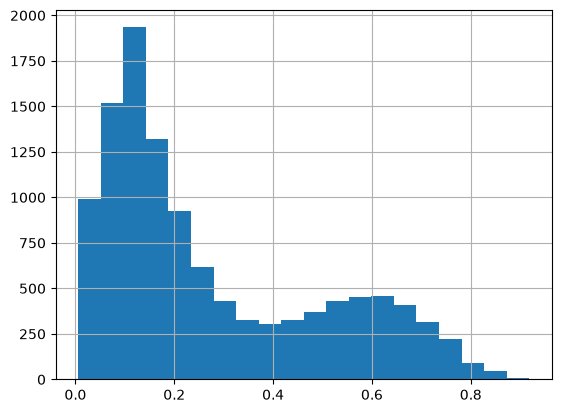

In [23]:
feature_df["stress_severity"].hist(bins=20)

Stress Risk Calculation with appropriate relations--------->

In [24]:
import pandas as pd
feature_df["stress_risk_candidate"] = pd.cut(
    feature_df["stress_severity"],
    bins=[-np.inf, 0.30, 0.60, np.inf],
    labels=["Low", "Moderate", "High"]
)

feature_df["stress_risk_candidate"].value_counts(
    normalize=True
).mul(100).round(2)

stress_risk_candidate
Low         65.63
Moderate    21.04
High        13.32
Name: proportion, dtype: float64

In [25]:
feature_df["stress_risk_candidate"].value_counts()

stress_risk_candidate
Low         7548
Moderate    2420
High        1532
Name: count, dtype: int64

In [26]:
pd.crosstab(
    feature_df["week_type"],
    feature_df["stress_risk_candidate"],
    normalize="index"
).round(3)

stress_risk_candidate,Low,Moderate,High
week_type,,,
Deployment,0.018,0.605,0.376
Normal,0.932,0.068,0.000
Operational_Spike,0.013,0.510,0.477
Recovery,1.000,0.000,0.000


In [27]:
print(feature_df["stress_risk_candidate"].isna().sum())

1500


In [28]:
feature_df["stress_risk"] = feature_df["stress_risk_candidate"]

Fatigue Risk calculation with appropriate solutions----->

Converting sleep_deviation-------sleep_pressure ========
0 → person's sleep baseline ke aas-paas ya better
0.5 → moderate sleep loss
1 → substantial sleep loss relative to prototype range

Ye medical threshold nahi hai, sirf synthetic-data normalization hai.


In [29]:
feature_df["sleep_pressure"] = positive_pressure(
    feature_df["sleep_deviation"],
    0,
    2
)

In [30]:
print(feature_df["sleep_deviation"].head(10))

0   -0.1
1   -0.1
2    0.2
3    0.4
4   -0.2
5   -0.1
6    0.0
7    0.8
8   -0.3
9   -0.4
Name: sleep_deviation, dtype: float64


Converting ===Fatigue trend---------- Fatigue pressure

In [31]:
feature_df["fatigue_trend_pressure"] = positive_pressure(
    feature_df["fatigue_trend"],
    0,
    0.5
)

In [32]:
print(feature_df["fatigue_trend"].head(10))

0     NaN
1     NaN
2     NaN
3    0.22
4    0.01
5    0.10
6   -0.11
7    0.41
8    0.02
9   -0.31
Name: fatigue_trend, dtype: float64


In [33]:
feature_df["fatigue_severity"] = (
    0.30 * feature_df["fatigue_pressure"]
    + 0.25 * feature_df["workload_index"]
    + 0.20 * feature_df["sleep_pressure"]
    + 0.15 * feature_df["fatigue_trend_pressure"]
    + 0.10 * feature_df["signal_agreement"]
)

In [34]:
print(feature_df["fatigue_severity"].describe())

count    11500.000000
mean         0.266027
std          0.208846
min          0.005826
25%          0.099283
50%          0.185666
75%          0.420610
max          0.819621
Name: fatigue_severity, dtype: float64


In [35]:
feature_df["fatigue_severity"].quantile([0.50, 0.75, 0.90, 0.95])

0.50    0.185666
0.75    0.420610
0.90    0.608973
0.95    0.670789
Name: fatigue_severity, dtype: float64

In [36]:
pd.crosstab(
    feature_df["week_type"],
    pd.cut(
        feature_df["fatigue_severity"],
        bins=[-np.inf, 0.30, 0.60, np.inf],
        labels=["Low", "Moderate", "High"]
    ),
    normalize="index"
)

fatigue_severity,Low,Moderate,High
week_type,,,
Deployment,0.043130,0.661738,0.295132
Normal,0.917984,0.082016,0.000000
Operational_Spike,0.026411,0.584671,0.388918
Recovery,1.000000,0.000000,0.000000


data leakage checkpoint


In [37]:
feature_df[
    [
        "fatigue_severity",
        "fatigue_pressure",
        "workload_index",
        "sleep_pressure",
        "fatigue_trend_pressure",
        "signal_agreement"
    ]
].corr()["fatigue_severity"].sort_values(ascending=False)

fatigue_severity          1.000000
fatigue_pressure          0.943656
sleep_pressure            0.870882
workload_index            0.867739
fatigue_trend_pressure    0.847617
signal_agreement          0.829048
Name: fatigue_severity, dtype: float64

In [38]:
feature_df["operational_strain"] = (
    0.25 * feature_df["duty_pressure"]
    + 0.15 * feature_df["overtime_pressure"]
    + 0.15 * feature_df["night_pressure"]
    + 0.15 * feature_df["consecutive_pressure"]
    + 0.10 * feature_df["rest_pressure"]
    + 0.05 * feature_df["training_pressure"]
    + 0.10 * feature_df["deployment_pressure"]
    + 0.05 * positive_pressure(
        feature_df["days_since_last_deployment"],
        0,
        90
    )
)

feature_df["operational_strain"].describe()

count    13000.000000
mean         0.333686
std          0.144486
min          0.030139
25%          0.228732
50%          0.287058
75%          0.475813
max          0.740601
Name: operational_strain, dtype: float64

In [39]:
feature_df["recovery_deficit"] = (
    0.30 * feature_df["sleep_pressure"]
    + 0.20 * positive_pressure(
        5 - feature_df["sleep_quality"],
        0,
        4
    )
    + 0.20 * feature_df["rest_pressure"]
    + 0.15 * positive_pressure(
        feature_df["days_since_last_leave"],
        0,
        60
    )
    + 0.10 * positive_pressure(
        feature_df["consecutive_duty_days"],
        1,
        10
    )
    + 0.05 * positive_pressure(
        feature_df["leave_days_taken"],
        0,
        5
    )
)

feature_df["recovery_deficit"].describe()


count    13000.000000
mean         0.308107
std          0.115288
min          0.026111
25%          0.227689
50%          0.301970
75%          0.385808
max          0.667172
Name: recovery_deficit, dtype: float64

In [40]:
feature_df["wellness_strain"] = (
    0.30 * positive_pressure(
        feature_df["self_reported_stress"],
        1,
        5
    )
    + 0.25 * positive_pressure(
        feature_df["fatigue_level"],
        1,
        5
    )
    + 0.20 * positive_pressure(
        feature_df["mood_score"],
        1,
        5
    )
    + 0.15 * positive_pressure(
        5 - feature_df["recovery_feeling"],
        0,
        4
    )
    + 0.10 * positive_pressure(
        5 - feature_df["sleep_quality"],
        0,
        4
    )
)

feature_df["wellness_strain"].describe()

count    13000.000000
mean         0.390588
std          0.118411
min          0.072500
25%          0.306250
50%          0.372500
75%          0.472500
max          0.870000
Name: wellness_strain, dtype: float64

In [41]:
feature_df["underlying_strain"] = (
    feature_df["operational_strain"]
    + feature_df["recovery_deficit"]
    + feature_df["wellness_strain"]
) / 3

feature_df["underlying_strain"].describe()

count    13000.000000
mean         0.344127
std          0.117422
min          0.071870
25%          0.264033
50%          0.312532
75%          0.449923
max          0.697088
Name: underlying_strain, dtype: float64

In [42]:
rng = np.random.default_rng(42)

In [43]:
latent_strains = []

for personnel_id, group in feature_df.groupby("personnel_id"):
    previous_latent = 0.0

    for idx in group.index:
        current_strain = feature_df.loc[idx, "underlying_strain"]

        noise = rng.normal(0, 0.08)

        latent = (
            0.65 * current_strain
            + 0.25 * previous_latent
            + 0.10 * noise
        )

        latent = np.clip(latent, 0, 1)

        latent_strains.append((idx, latent))

        previous_latent = latent

latent_strains = dict(latent_strains)

feature_df["latent_strain"] = (
    feature_df.index.map(latent_strains)
)


feature_df["latent_strain"].describe()

count    13000.000000
mean         0.294279
std          0.084895
min          0.065831
25%          0.232116
50%          0.276592
75%          0.360232
max          0.565123
Name: latent_strain, dtype: float64

In [44]:
feature_df[
    feature_df["personnel_id"] == "P001"
][
    [
        "week_index",
        "week_type",
        "underlying_strain",
        "latent_strain"
    ]
]

,week_index,week_type,underlying_strain,latent_strain
0,1,Normal,0.232492,0.153558
1,2,Normal,0.224526,0.176011
2,3,Normal,0.288671,0.237642
3,4,Deployment,0.456868,0.363899
4,5,Normal,0.264230,0.247116
5,6,Normal,0.281292,0.234202
6,7,Normal,0.315158,0.264426
7,8,Operational_Spike,0.518776,0.400781
8,9,Normal,0.220971,0.243692
9,10,Recovery,0.156602,0.155890


Target generation-----------------------------

In [45]:
stress_noise = rng.normal(0, 0.08, size=len(feature_df))

feature_df["stress_target_score"] = np.clip(
    0.55 * feature_df["latent_strain"]
    + 0.20 * feature_df["wellness_strain"]
    + 0.15 * feature_df["operational_strain"]
    + 0.10 * feature_df["stress_trend_pressure"].fillna(0)
    + stress_noise,
    0,
    1
)

In [46]:
feature_df["stress_target_score"].describe()

count    13000.000000
mean         0.310382
std          0.133282
min          0.000000
25%          0.214974
50%          0.297283
75%          0.398851
max          0.787460
Name: stress_target_score, dtype: float64

In [47]:
feature_df["stress_target_score"].quantile(
    [0.50, 0.75, 0.90, 0.95]
)

0.50    0.297283
0.75    0.398851
0.90    0.493848
0.95    0.548755
Name: stress_target_score, dtype: float64

In [48]:
pd.crosstab(
    feature_df["week_type"],
    pd.cut(
        feature_df["stress_target_score"],
        bins=[-np.inf, 0.30, 0.60, np.inf],
        labels=["Low", "Moderate", "High"]
    ),
    normalize="index"
)

stress_target_score,Low,Moderate,High
week_type,,,
Deployment,0.075430,0.859124,0.065446
Normal,0.664228,0.335772,0.000000
Operational_Spike,0.061808,0.869465,0.068727
Recovery,0.918545,0.081455,0.000000


In [49]:
feature_df["stress_risk_candidate"] = pd.cut(
    feature_df["stress_target_score"],
    bins=[-np.inf, 0.30, 0.50, np.inf],
    labels=["Low", "Moderate", "High"]
)

In [50]:
feature_df["stress_risk_candidate"].value_counts(
    normalize=True
) * 100

stress_risk_candidate
Low         50.900000
Moderate    39.707692
High         9.392308
Name: proportion, dtype: float64

In [51]:
pd.crosstab(
    feature_df["week_type"],
    feature_df["stress_risk_candidate"],
    normalize="index"
)

stress_risk_candidate,Low,Moderate,High
week_type,,,
Deployment,0.075430,0.638935,0.285635
Normal,0.664228,0.331983,0.003789
Operational_Spike,0.061808,0.625923,0.312269
Recovery,0.918545,0.081455,0.000000


Target for Stress_level Risk locked.

In [52]:
feature_df["stress_risk"] = feature_df["stress_risk_candidate"]

Fatigue_Level ---------- begins./

In [53]:
fatigue_noise = rng.normal(0, 0.08, size=len(feature_df))

feature_df["fatigue_target_score"] = np.clip(
    0.40 * feature_df["latent_strain"]
    + 0.30 * feature_df["recovery_deficit"]
    + 0.15 * feature_df["operational_strain"]
    + 0.10 * feature_df["wellness_strain"]
    + fatigue_noise,
    0,
    1
)


feature_df["fatigue_target_score"].describe()

count    13000.000000
mean         0.299495
std          0.124798
min          0.000000
25%          0.212166
50%          0.289906
75%          0.386002
max          0.742848
Name: fatigue_target_score, dtype: float64

In [54]:
# # feature_df["fatigue_target_score"].quantile(
#     [0.50, 0.75, 0.90, 0.95]
# )

In [55]:
pd.crosstab(
    feature_df["week_type"],
    pd.cut(
        feature_df["fatigue_target_score"],
        bins=[-np.inf, 0.30, 0.50, np.inf],
        labels=["Low", "Moderate", "High"]
    ),
    normalize="index"
)

fatigue_target_score,Low,Moderate,High
week_type,,,
Deployment,0.107044,0.708264,0.184692
Normal,0.680298,0.315783,0.003920
Operational_Spike,0.089945,0.713100,0.196956
Recovery,0.943273,0.056727,0.000000


In [56]:
feature_df["fatigue_risk"] = feature_df["fatigue_target_score"].apply(
    lambda x: "Low" if x < 0.30
    else "Moderate" if x < 0.50
    else "High"
)

In [57]:
# feature_df["fatigue_risk"].value_counts(normalize=True) * 100


Fatigue_Level risk is locked

In [58]:
# feature_df["fatigue_risk"].isna().sum()

Burnout Risk Level

In [59]:
cumulative_strain = []

for personnel_id, group in feature_df.groupby("personnel_id"):
    previous_cumulative = 0.0

    for idx in group.index:
        latent = feature_df.loc[idx, "latent_strain"]

        cumulative = (
            0.70 * previous_cumulative
            + 0.30 * latent
        )

        cumulative = np.clip(cumulative, 0, 1)

        cumulative_strain.append((idx, cumulative))
        previous_cumulative = cumulative

cumulative_strain = dict(cumulative_strain)

feature_df["cumulative_strain"] = feature_df.index.map(
    cumulative_strain
)

In [60]:
# feature_df["cumulative_strain"].describe()

In [61]:
# feature_df.groupby("week_type")["cumulative_strain"].mean()

In [62]:
# feature_df[
#     feature_df["personnel_id"] == "P001"
# ][
#     ["week_index", "week_type", "latent_strain", "cumulative_strain"]
# ]

In [63]:
burnout_noise = rng.normal(0, 0.07, size=len(feature_df))

feature_df["burnout_target_score"] = np.clip(
    0.50 * feature_df["cumulative_strain"]
    + 0.20 * feature_df["latent_strain"]
    + 0.15 * feature_df["recovery_deficit"]
    + 0.10 * feature_df["wellness_strain"]
    + 0.05 * feature_df["stress_trend_pressure"].fillna(0)
    + burnout_noise,
    0,
    1
)

feature_df["burnout_target_score"].describe()

count    13000.000000
mean         0.285364
std          0.105112
min          0.000000
25%          0.213043
50%          0.282681
75%          0.355046
max          0.700895
Name: burnout_target_score, dtype: float64

In [64]:
feature_df["burnout_target_score"].quantile(
    [0.50, 0.75, 0.90, 0.95]
)

0.50    0.282681
0.75    0.355046
0.90    0.424488
0.95    0.462887
Name: burnout_target_score, dtype: float64

In [65]:
pd.crosstab(
    feature_df["week_type"],
    pd.cut(
        feature_df["burnout_target_score"],
        bins=[-np.inf, 0.30, 0.50, np.inf],
        labels=["Low", "Moderate", "High"]
    ),
    normalize="index"
)

burnout_target_score,Low,Moderate,High
week_type,,,
Deployment,0.223516,0.704382,0.072102
Normal,0.688137,0.309511,0.002352
Operational_Spike,0.201107,0.719557,0.079336
Recovery,0.896727,0.103273,0.000000


In [66]:
feature_df["burnout_risk_candidate"] = pd.cut(
    feature_df["burnout_target_score"],
    bins=[-np.inf, 0.30, 0.45, np.inf],
    labels=["Low", "Moderate", "High"]
)

In [67]:
print(
    feature_df["burnout_risk_candidate"]
    .value_counts(normalize=True)
    .mul(100)
)

print("\nWeek-type distribution:\n")

print(
    pd.crosstab(
        feature_df["week_type"],
        feature_df["burnout_risk_candidate"],
        normalize="index"
    )
)

burnout_risk_candidate
Low         56.453846
Moderate    36.953846
High         6.592308
Name: proportion, dtype: float64

Week-type distribution:

burnout_risk_candidate       Low  Moderate      High
week_type                                           
Deployment              0.223516  0.600666  0.175818
Normal                  0.688137  0.300235  0.011628
Operational_Spike       0.201107  0.592712  0.206181
Recovery                0.896727  0.100364  0.002909


In [68]:
feature_df["burnout_risk"] = feature_df["burnout_risk_candidate"]

In [69]:
print("=== TARGET DISTRIBUTIONS ===\n")

print("Stress Risk:")
print(
    feature_df["stress_risk"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("\nFatigue Risk:")
print(
    feature_df["fatigue_risk"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("\nBurnout Risk:")
print(
    feature_df["burnout_risk"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

=== TARGET DISTRIBUTIONS ===

Stress Risk:
stress_risk
Low         50.90
Moderate    39.71
High         9.39
Name: proportion, dtype: float64

Fatigue Risk:
fatigue_risk
Low         53.02
Moderate    40.91
High         6.08
Name: proportion, dtype: float64

Burnout Risk:
burnout_risk
Low         56.45
Moderate    36.95
High         6.59
Name: proportion, dtype: float64


In [70]:
# print("=== MISSING TARGET VALUES ===\n")

# print(
#     feature_df[
#         ["stress_risk", "fatigue_risk", "burnout_risk"]
#     ].isna().sum()
# )

In [71]:
# risk_numeric = feature_df[
#     ["stress_risk", "fatigue_risk", "burnout_risk"]
# ].astype(str).replace(
#     {"Low": 0, "Moderate": 1, "High": 2}
# )

# risk_numeric.corr()

let's see the data we have generated _________

In [72]:
from pathlib import Path

# Output folder
output_dir = PROJECT_ROOT / "data" / "processed"
output_dir.mkdir(parents=True, exist_ok=True)

# Full synthetic dataset
full_path = output_dir / "synthetic_full.csv"
feature_df.to_csv(full_path, index=False)

# Excel version
excel_path = output_dir / "synthetic_full.xlsx"

with pd.ExcelWriter(excel_path, engine="openpyxl") as writer:
    feature_df.to_excel(
        writer,
        sheet_name="Full Synthetic Data",
        index=False
    )

print("✅ Dataset exported successfully!")
print(f"CSV   : {full_path}")
print(f"Excel : {excel_path}")
print(f"Shape : {feature_df.shape}")

✅ Dataset exported successfully!
CSV   : j:\TRINETRA_ML\data\processed\synthetic_full.csv
Excel : j:\TRINETRA_ML\data\processed\synthetic_full.xlsx
Shape : (13000, 69)


Now- Starts the Data Cleaning Process----->

In [73]:
print("Total rows:", len(feature_df))

duplicate_count = feature_df.duplicated().sum()

print("Duplicate rows:", duplicate_count)

Total rows: 13000
Duplicate rows: 0


In [74]:
duplicate_keys = feature_df.duplicated(
    subset=["personnel_id", "week_index"]
).sum()

print("Duplicate personnel-week records:", duplicate_keys)

Duplicate personnel-week records: 0


In [75]:
missing_values = feature_df.isna().sum()

print(missing_values[missing_values > 0])

workload_trend            1500
stress_trend              1500
fatigue_trend             1500
sleep_trend               1500
signal_agreement          1500
stress_trend_pressure     1500
stress_severity           1500
fatigue_trend_pressure    1500
fatigue_severity          1500
dtype: int64


In [76]:
unexpected_missing = feature_df.isna().sum()

print(
    unexpected_missing[
        (unexpected_missing > 0) &
        (~unexpected_missing.index.isin([
            "workload_trend",
            "stress_trend",
            "fatigue_trend",
            "sleep_trend",
            "signal_agreement",
            "stress_trend_pressure",
            "fatigue_trend_pressure",
            "stress_severity",
            "fatigue_severity"
        ]))
    ]
)

Series([], dtype: int64)


In [77]:
wellness_columns = [
    "sleep_quality",
    "self_reported_stress",
    "fatigue_level",
    "mood_score",
    "recovery_feeling"
]

for col in wellness_columns:
    print(
        f"{col:25s}",
        "min =", feature_df[col].min(),
        "max =", feature_df[col].max()
    )

sleep_quality             min = 1.9 max = 5.0
self_reported_stress      min = 1.0 max = 5.0
fatigue_level             min = 1.0 max = 5.0
mood_score                min = 1.0 max = 3.5
recovery_feeling          min = 1.2 max = 5.0


In [78]:
operational_columns = [
    "duty_hours_week",
    "overtime_hours",
    "night_shifts",
    "consecutive_duty_days",
    "avg_rest_hours",
    "training_hours",
    "current_deployment_days",
    "days_since_last_deployment",
    "recent_deployment_count",
    "leave_days_taken",
    "days_since_last_leave",
    "avg_sleep_hours"
]

for col in operational_columns:
    print(
        f"{col:30s}",
        "min =", feature_df[col].min(),
        "max =", feature_df[col].max()
    )

duty_hours_week                min = 30.0 max = 72.3
overtime_hours                 min = 0.0 max = 14.0
night_shifts                   min = 0 max = 4
consecutive_duty_days          min = 1 max = 7
avg_rest_hours                 min = 5.0 max = 16.0
training_hours                 min = 0.0 max = 8.0
current_deployment_days        min = 0 max = 7
days_since_last_deployment     min = 0 max = 355
recent_deployment_count        min = 0 max = 8
leave_days_taken               min = 0 max = 5
days_since_last_leave          min = 0 max = 226
avg_sleep_hours                min = 4.8 max = 8.6


In [79]:
engineered_columns = [
    "workload_index",
    "duty_deviation",
    "sleep_deviation",
    "stress_deviation",
    "fatigue_deviation",
    "signal_agreement",
    "stress_pressure",
    "fatigue_pressure",
    "stress_trend_pressure"
]

for col in engineered_columns:
    print(
        f"{col:25s}",
        "min =", feature_df[col].min(),
        "max =", feature_df[col].max()
    )

workload_index            min = 0.02330357142857143 max = 0.7874188311688312
duty_deviation            min = -10.399999999999999 max = 16.400000000000006
sleep_deviation           min = -1.2999999999999998 max = 1.2000000000000002
stress_deviation          min = -1.0 max = 2.3
fatigue_deviation         min = -1.0999999999999999 max = 2.6000000000000005
signal_agreement          min = 0.0 max = 1.0
stress_pressure           min = 0.0 max = 1.0
fatigue_pressure          min = 0.0 max = 1.0
stress_trend_pressure     min = 0.0 max = 1.0


In [80]:
weeks_per_person = feature_df.groupby("personnel_id")["week_index"].nunique()

print("Minimum weeks:", weeks_per_person.min())
print("Maximum weeks:", weeks_per_person.max())

print("\nPersonnel with != 26 weeks:")
print(weeks_per_person[weeks_per_person != 26])

Minimum weeks: 26
Maximum weeks: 26

Personnel with != 26 weeks:
Series([], Name: week_index, dtype: int64)


In [81]:
invalid_sequences = []

for personnel_id, group in feature_df.groupby("personnel_id"):
    weeks = sorted(group["week_index"].tolist())

    expected = list(range(1, 27))

    if weeks != expected:
        invalid_sequences.append(personnel_id)

print("Personnel with invalid week sequence:", len(invalid_sequences))

Personnel with invalid week sequence: 0


In [82]:
print("Role categories:")
print(feature_df["role_category"].value_counts())

print("\nPosting categories:")
print(feature_df["posting_type"].value_counts())

print("\nWeek types:")
print(feature_df["week_type"].value_counts())

Role categories:
role_category
Field             5174
Administrative    3068
Technical         2600
Support           2158
Name: count, dtype: int64

Posting categories:
posting_type
Routine             6838
High_Operational    3848
Remote              2314
Name: count, dtype: int64

Week types:
week_type
Normal               7654
Operational_Spike    2168
Deployment           1803
Recovery             1375
Name: count, dtype: int64


In [83]:
print("Total personnel:", feature_df["personnel_id"].nunique())
print("Total rows:", len(feature_df))

print(
    "Expected rows:",
    feature_df["personnel_id"].nunique() * 26
)

Total personnel: 500
Total rows: 13000
Expected rows: 13000


Target Sanity Check-----

In [84]:
target_columns = [
    "stress_risk",
    "fatigue_risk",
    "burnout_risk"
]

for target in target_columns:
    print(f"\n{target}")
    print(feature_df[target].value_counts())
    print(
        feature_df[target]
        .value_counts(normalize=True)
        .mul(100)
        .round(2)
    )


stress_risk
stress_risk
Low         6617
Moderate    5162
High        1221
Name: count, dtype: int64
stress_risk
Low         50.90
Moderate    39.71
High         9.39
Name: proportion, dtype: float64

fatigue_risk
fatigue_risk
Low         6892
Moderate    5318
High         790
Name: count, dtype: int64
fatigue_risk
Low         53.02
Moderate    40.91
High         6.08
Name: proportion, dtype: float64

burnout_risk
burnout_risk
Low         7339
Moderate    4804
High         857
Name: count, dtype: int64
burnout_risk
Low         56.45
Moderate    36.95
High         6.59
Name: proportion, dtype: float64


In [85]:
for target in target_columns:
    print(
        target,
        "→",
        feature_df[target].dropna().unique()
    )

stress_risk → ['Low', 'Moderate', 'High']
Categories (3, str): ['Low' < 'Moderate' < 'High']
fatigue_risk → <StringArray>
['Low', 'Moderate', 'High']
Length: 3, dtype: str
burnout_risk → ['Low', 'Moderate', 'High']
Categories (3, str): ['Low' < 'Moderate' < 'High']


In [86]:
print(
    feature_df[target_columns]
    .isna()
    .sum()
)

stress_risk     0
fatigue_risk    0
burnout_risk    0
dtype: int64


ML features------------------------------------------------------------------------->

In [87]:
print(feature_df.columns)

Index(['personnel_id', 'week_index', 'role_category', 'posting_type',
       'service_tenure_months', 'week_type', 'duty_hours_week',
       'overtime_hours', 'night_shifts', 'consecutive_duty_days',
       'avg_rest_hours', 'training_hours', 'current_deployment_days',
       'days_since_last_deployment', 'recent_deployment_count',
       'leave_days_taken', 'days_since_last_leave', 'avg_sleep_hours',
       'sleep_quality', 'self_reported_stress', 'fatigue_level', 'mood_score',
       'recovery_feeling', 'baseline_duty_hours', 'baseline_sleep_hours',
       'baseline_stress', 'baseline_fatigue', 'duty_deviation',
       'sleep_deviation', 'stress_deviation', 'fatigue_deviation',
       'duty_pressure', 'overtime_pressure', 'night_pressure',
       'consecutive_pressure', 'rest_pressure', 'training_pressure',
       'deployment_pressure', 'workload_index', 'workload_trend',
       'stress_trend', 'fatigue_trend', 'sleep_trend',
       'workload_deteriorating', 'stress_deteriorating',
 

In [88]:
ml_feature_columns = [
    # Context
    "role_category",
    "posting_type",
    "service_tenure_months",

    # Duty / workload
    "duty_hours_week",
    "overtime_hours",
    "night_shifts",
    "consecutive_duty_days",
    "avg_rest_hours",
    "training_hours",

    # Deployment
    "current_deployment_days",
    "days_since_last_deployment",
    "recent_deployment_count",

    # Leave / stability
    "leave_days_taken",
    "days_since_last_leave",

    # Sleep / wellness
    "avg_sleep_hours",
    "sleep_quality",
    "self_reported_stress",
    "fatigue_level",
    "mood_score",
    "recovery_feeling",

    # Personal deviations
    "duty_deviation",
    "sleep_deviation",
    "stress_deviation",
    "fatigue_deviation",

    # Engineered workload
    "workload_index",

    # Temporal trends
    "workload_trend",
    "stress_trend",
    "fatigue_trend",
    "sleep_trend",

    # Signal consistency
    "signal_agreement",

    # Pressure features
    "stress_pressure",
    "fatigue_pressure",
    "stress_trend_pressure"
]

target_columns = [
    "stress_risk",
    "fatigue_risk",
    "burnout_risk"
]

In [89]:
ml_df = feature_df[
    ml_feature_columns + target_columns
].copy()

print("ML dataset shape:", ml_df.shape)

print("\nNumber of features:", len(ml_feature_columns))
print("Number of targets:", len(target_columns))

print("\nFeatures:")
print(ml_feature_columns)

ML dataset shape: (13000, 36)

Number of features: 33
Number of targets: 3

Features:
['role_category', 'posting_type', 'service_tenure_months', 'duty_hours_week', 'overtime_hours', 'night_shifts', 'consecutive_duty_days', 'avg_rest_hours', 'training_hours', 'current_deployment_days', 'days_since_last_deployment', 'recent_deployment_count', 'leave_days_taken', 'days_since_last_leave', 'avg_sleep_hours', 'sleep_quality', 'self_reported_stress', 'fatigue_level', 'mood_score', 'recovery_feeling', 'duty_deviation', 'sleep_deviation', 'stress_deviation', 'fatigue_deviation', 'workload_index', 'workload_trend', 'stress_trend', 'fatigue_trend', 'sleep_trend', 'signal_agreement', 'stress_pressure', 'fatigue_pressure', 'stress_trend_pressure']


In [90]:
ml_df.head()

,role_category,posting_type,service_tenure_months,duty_hours_week,overtime_hours,night_shifts,consecutive_duty_days,avg_rest_hours,training_hours,current_deployment_days,...,stress_trend,fatigue_trend,sleep_trend,signal_agreement,stress_pressure,fatigue_pressure,stress_trend_pressure,stress_risk,fatigue_risk,burnout_risk
0,Technical,Routine,111,43.8,3.9,0,2,12.4,3.9,0,...,NaN,NaN,NaN,NaN,0.00,0.00,NaN,Low,Low,Low
1,Technical,Routine,111,44.5,3.5,0,4,13.3,2.0,0,...,NaN,NaN,NaN,NaN,0.00,0.20,NaN,Low,Low,Low
2,Technical,Routine,111,44.4,3.9,0,4,11.6,3.0,0,...,NaN,NaN,NaN,NaN,0.25,0.00,NaN,Moderate,Low,Low
3,Technical,Routine,111,51.8,4.7,2,7,10.3,1.1,7,...,0.53,0.22,-0.18,1.00,0.65,0.45,1.00,Moderate,Moderate,Moderate
4,Technical,Routine,111,45.5,1.3,0,3,9.7,0.8,0,...,0.23,0.01,0.01,0.25,0.00,0.05,0.46,Moderate,Low,Low


In [91]:
print(ml_df.shape, ml_df.size)



(13000, 36) 468000


In [92]:
print(ml_df.columns)

Index(['role_category', 'posting_type', 'service_tenure_months',
       'duty_hours_week', 'overtime_hours', 'night_shifts',
       'consecutive_duty_days', 'avg_rest_hours', 'training_hours',
       'current_deployment_days', 'days_since_last_deployment',
       'recent_deployment_count', 'leave_days_taken', 'days_since_last_leave',
       'avg_sleep_hours', 'sleep_quality', 'self_reported_stress',
       'fatigue_level', 'mood_score', 'recovery_feeling', 'duty_deviation',
       'sleep_deviation', 'stress_deviation', 'fatigue_deviation',
       'workload_index', 'workload_trend', 'stress_trend', 'fatigue_trend',
       'sleep_trend', 'signal_agreement', 'stress_pressure',
       'fatigue_pressure', 'stress_trend_pressure', 'stress_risk',
       'fatigue_risk', 'burnout_risk'],
      dtype='str')


In [93]:
# Keep only weeks with sufficient history for 4-week rolling features
ml_source = feature_df[
    feature_df["week_index"] >= 4
].copy()

# Create ML dataset
ml_df = ml_source[
    ml_feature_columns + target_columns
].copy()

print("ML dataset shape:", ml_df.shape)
print("Minimum week:", ml_source["week_index"].min())
print("Maximum week:", ml_source["week_index"].max())

print("\nMissing values:")
print(
    ml_df.isna().sum()[
        ml_df.isna().sum() > 0
    ]
)

ML dataset shape: (11500, 36)
Minimum week: 4
Maximum week: 26

Missing values:
Series([], dtype: int64)


Two Features : 1. Current 2. Predictive(Future)

Future target----->

In [94]:
future_df = feature_df[
    feature_df["week_index"].between(4, 25)
].copy()

print("Future prediction dataset shape:", future_df.shape)

Future prediction dataset shape: (11000, 69)


In [95]:
future_df["next_stress_risk"] = (
    future_df
    .groupby("personnel_id")["stress_risk"]
    .shift(-1)
)

future_df["next_fatigue_risk"] = (
    future_df
    .groupby("personnel_id")["fatigue_risk"]
    .shift(-1)
)

future_df["next_burnout_risk"] = (
    future_df
    .groupby("personnel_id")["burnout_risk"]
    .shift(-1)
)

In [96]:
#  demo for 10 rows

future_df[
    future_df["personnel_id"] == "P001"
][
    [
        "personnel_id",
        "week_index",
        "stress_risk",
        "next_stress_risk",
        "fatigue_risk",
        "next_fatigue_risk",
        "burnout_risk",
        "next_burnout_risk"
    ]
].head(10)

,personnel_id,week_index,stress_risk,next_stress_risk,fatigue_risk,next_fatigue_risk,burnout_risk,next_burnout_risk
3,P001,4,Moderate,Moderate,Moderate,Low,Moderate,Low
4,P001,5,Moderate,Moderate,Low,Low,Low,Low
5,P001,6,Moderate,Moderate,Low,Moderate,Low,Low
6,P001,7,Moderate,High,Moderate,Moderate,Low,Moderate
7,P001,8,High,Low,Moderate,Moderate,Moderate,Low
8,P001,9,Low,Low,Moderate,Low,Low,Low
9,P001,10,Low,Moderate,Low,Moderate,Low,Low
10,P001,11,Moderate,Moderate,Moderate,Low,Low,Low
11,P001,12,Moderate,Low,Low,Low,Low,Low
12,P001,13,Low,Moderate,Low,Moderate,Low,Moderate


In [97]:
future_ml_df = future_df[
    ml_feature_columns
    + [
        "next_stress_risk",
        "next_fatigue_risk",
        "next_burnout_risk"
    ]
].copy()

print("Future ML dataset shape:", future_ml_df.shape)
print("Number of features:", len(ml_feature_columns))
print("Number of targets:", 3)

Future ML dataset shape: (11000, 36)
Number of features: 33
Number of targets: 3


In [98]:
alignment_check = (
    future_df["next_stress_risk"].reset_index(drop=True)
    ==
    future_df.groupby("personnel_id")["stress_risk"]
    .shift(-1)
    .reset_index(drop=True)
)

print("Stress target alignment:", alignment_check.all())

Stress target alignment: False


In [99]:
week_check = []

for personnel_id, group in future_df.groupby("personnel_id"):
    weeks = group["week_index"].to_numpy()

    week_check.extend(
        (weeks[1:] == weeks[:-1] + 1)
    )

print("All future prediction weeks consecutive:", all(week_check))

All future prediction weeks consecutive: True


In [100]:
future_df = feature_df.copy()

future_df["next_stress_risk"] = (
    future_df
    .groupby("personnel_id")["stress_risk"]
    .shift(-1)
)

future_df["next_fatigue_risk"] = (
    future_df
    .groupby("personnel_id")["fatigue_risk"]
    .shift(-1)
)

future_df["next_burnout_risk"] = (
    future_df
    .groupby("personnel_id")["burnout_risk"]
    .shift(-1)
)

# Now keep only weeks that have a next-week target
future_df = future_df[
    future_df["week_index"].between(4, 25)
].copy()

print("Shape:", future_df.shape)
print("Week range:", future_df["week_index"].min(),
      "to", future_df["week_index"].max())

Shape: (11000, 72)
Week range: 4 to 25


In [101]:
future_df[
    future_df["personnel_id"] == "P001"
][
    [
        "personnel_id",
        "week_index",
        "stress_risk",
        "next_stress_risk"
    ]
].tail(5)

,personnel_id,week_index,stress_risk,next_stress_risk
20,P001,21,Low,Low
21,P001,22,Low,Low
22,P001,23,Low,High
23,P001,24,High,Low
24,P001,25,Low,Low


In [102]:
expected_next_stress = (
    feature_df
    .groupby("personnel_id")["stress_risk"]
    .shift(-1)
)

expected_next_stress = expected_next_stress.loc[
    future_df.index
]

print(
    "Stress target alignment:",
    future_df["next_stress_risk"].equals(expected_next_stress)
)

Stress target alignment: True


Splitting the Data--------->

In [103]:
train_mask = future_df["week_index"].between(4, 17)
val_mask = future_df["week_index"].between(18, 21)
test_mask = future_df["week_index"].between(22, 25)

train_future = future_df.loc[train_mask].copy()
val_future = future_df.loc[val_mask].copy()
test_future = future_df.loc[test_mask].copy()

print("Train:", train_future.shape)
print("Validation:", val_future.shape)
print("Test:", test_future.shape)

Train: (7000, 72)
Validation: (2000, 72)
Test: (2000, 72)


In [104]:
print(
    "Train weeks:",
    train_future["week_index"].min(),
    "to",
    train_future["week_index"].max()
)

print(
    "Validation weeks:",
    val_future["week_index"].min(),
    "to",
    val_future["week_index"].max()
)

print(
    "Test weeks:",
    test_future["week_index"].min(),
    "to",
    test_future["week_index"].max()
)

Train weeks: 4 to 17
Validation weeks: 18 to 21
Test weeks: 22 to 25


Seperating the X and Y

In [105]:
X_train = train_future[ml_feature_columns].copy()
X_val = val_future[ml_feature_columns].copy()
X_test = test_future[ml_feature_columns].copy()

y_train_stress = train_future["next_stress_risk"].copy()
y_val_stress = val_future["next_stress_risk"].copy()
y_test_stress = test_future["next_stress_risk"].copy()

y_train_fatigue = train_future["next_fatigue_risk"].copy()
y_val_fatigue = val_future["next_fatigue_risk"].copy()
y_test_fatigue = test_future["next_fatigue_risk"].copy()

y_train_burnout = train_future["next_burnout_risk"].copy()
y_val_burnout = val_future["next_burnout_risk"].copy()
y_test_burnout = test_future["next_burnout_risk"].copy()

In [106]:
print("X shapes:")
print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

print("\nTarget shapes:")
print("Stress:", y_train_stress.shape)
print("Fatigue:", y_train_fatigue.shape)
print("Burnout:", y_train_burnout.shape)

X shapes:
Train: (7000, 33)
Validation: (2000, 33)
Test: (2000, 33)

Target shapes:
Stress: (7000,)
Fatigue: (7000,)
Burnout: (7000,)


Preprocessing Pipeline

In [107]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

categorical_features = [
    "role_category",
    "posting_type"
]

numeric_features = [
    col
    for col in ml_feature_columns
    if col not in categorical_features
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features
        ),
        (
            "numeric",
            "passthrough",
            numeric_features
        )
    ]
)

In [108]:
X_train_encoded = preprocessor.fit_transform(X_train)

X_val_encoded = preprocessor.transform(X_val)

X_test_encoded = preprocessor.transform(X_test)

print("Encoded train shape:", X_train_encoded.shape)
print("Encoded validation shape:", X_val_encoded.shape)
print("Encoded test shape:", X_test_encoded.shape)

Encoded train shape: (7000, 38)
Encoded validation shape: (2000, 38)
Encoded test shape: (2000, 38)


In [109]:
for name, target in [
    ("Stress", y_train_stress),
    ("Fatigue", y_train_fatigue),
    ("Burnout", y_train_burnout)
]:
    print(f"\n{name} — Training distribution")
    print(
        target.value_counts(normalize=True)
        .mul(100)
        .round(2)
    )


Stress — Training distribution
next_stress_risk
Low         50.04
Moderate    39.74
High        10.21
Name: proportion, dtype: float64

Fatigue — Training distribution
next_fatigue_risk
Low         52.71
Moderate    41.00
High         6.29
Name: proportion, dtype: float64

Burnout — Training distribution
next_burnout_risk
Low         53.1
Moderate    39.7
High         7.2
Name: proportion, dtype: float64


Logistic Regression Base Pipeline-------------->>>


In [110]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

stress_model = Pipeline([
    (
        "preprocessor",
        preprocessor
    ),
    (
        "scaler",
        StandardScaler()
    ),
    (
        "classifier",
        LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            random_state=42
        )
    )
])

In [111]:
stress_model.fit(
    X_train,
    y_train_stress
)

print("✅ Stress model trained successfully!")

✅ Stress model trained successfully!


In [112]:
stress_val_pred = stress_model.predict(X_val)

print(stress_val_pred[:20])

['High' 'Low' 'High' 'Low' 'Low' 'Moderate' 'High' 'Moderate' 'Moderate'
 'High' 'High' 'High' 'High' 'High' 'Moderate' 'Moderate' 'Low' 'Moderate'
 'High' 'High']


In [113]:
print(y_val_stress.iloc[:20].to_numpy())

['Low' 'Moderate' 'Low' 'Low' 'Low' 'Low' 'Moderate' 'Low' 'Moderate'
 'Moderate' 'Low' 'Moderate' 'Low' 'Low' 'Low' 'Low' 'Low' 'Moderate'
 'High' 'Low']


In [114]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)

print("Validation Accuracy:")
print(accuracy_score(y_val_stress, stress_val_pred))

print("\nClassification Report:")
print(
    classification_report(
        y_val_stress,
        stress_val_pred,
        labels=["Low", "Moderate", "High"],
        zero_division=0
    )
)

Validation Accuracy:
0.41

Classification Report:
              precision    recall  f1-score   support

         Low       0.59      0.56      0.58       986
    Moderate       0.44      0.19      0.27       830
        High       0.15      0.57      0.24       184

    accuracy                           0.41      2000
   macro avg       0.40      0.44      0.36      2000
weighted avg       0.49      0.41      0.42      2000



In [115]:
cm = confusion_matrix(
    y_val_stress,
    stress_val_pred,
    labels=["Low", "Moderate", "High"]
)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[554 168 264]
 [337 161 332]
 [ 45  34 105]]


In [116]:
baseline_results = {
    "model": "Logistic Regression",
    "accuracy": 0.41,
    "high_precision": 0.15,
    "high_recall": 0.57
}

baseline_results

{'model': 'Logistic Regression',
 'accuracy': 0.41,
 'high_precision': 0.15,
 'high_recall': 0.57}

Experiment 2 — same Logistic Regression, but WITHOUT class_weight="balanced"----------->>>>>>>>.

In [117]:
stress_model_unbalanced = Pipeline([
    ("preprocessor", preprocessor),
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])


In [118]:
stress_model_unbalanced.fit(
    X_train,
    y_train_stress
)

print("✅ Unbalanced Stress model trained!")

✅ Unbalanced Stress model trained!


In [119]:
stress_val_pred_unbalanced = stress_model_unbalanced.predict(X_val)

In [120]:
print("Validation Accuracy:")
print(
    accuracy_score(
        y_val_stress,
        stress_val_pred_unbalanced
    )
)

print("\nClassification Report:")
print(
    classification_report(
        y_val_stress,
        stress_val_pred_unbalanced,
        labels=["Low", "Moderate", "High"],
        zero_division=0
    )
)

Validation Accuracy:
0.537

Classification Report:
              precision    recall  f1-score   support

         Low       0.55      0.82      0.66       986
    Moderate       0.49      0.32      0.39       830
        High       0.00      0.00      0.00       184

    accuracy                           0.54      2000
   macro avg       0.35      0.38      0.35      2000
weighted avg       0.48      0.54      0.49      2000



In [121]:
cm_unbalanced = confusion_matrix(
    y_val_stress,
    stress_val_pred_unbalanced,
    labels=["Low", "Moderate", "High"]
)

print("\nConfusion Matrix:")
print(cm_unbalanced)


Confusion Matrix:
[[810 176   0]
 [566 264   0]
 [ 85  99   0]]


Random Forest Baseline---------------------->>>>>>>>>>>>>>

In [122]:
from sklearn.ensemble import RandomForestClassifier

stress_rf = Pipeline([
    ("preprocessor", preprocessor),
    (
        "classifier",
        RandomForestClassifier(
            n_estimators=300,
            max_depth=None,
            min_samples_leaf=2,
            random_state=42,
            n_jobs=-1
        )
    )
])

In [123]:
stress_rf.fit(
    X_train,
    y_train_stress
)

print("✅ Random Forest Stress model trained!")

✅ Random Forest Stress model trained!


In [124]:
stress_rf_val_pred = stress_rf.predict(X_val)

In [125]:
print("Validation Accuracy:")
print(
    accuracy_score(
        y_val_stress,
        stress_rf_val_pred
    )
)

print("\nClassification Report:")
print(
    classification_report(
        y_val_stress,
        stress_rf_val_pred,
        labels=["Low", "Moderate", "High"],
        zero_division=0
    )
)

Validation Accuracy:
0.5315

Classification Report:
              precision    recall  f1-score   support

         Low       0.55      0.80      0.65       986
    Moderate       0.49      0.33      0.39       830
        High       0.00      0.00      0.00       184

    accuracy                           0.53      2000
   macro avg       0.35      0.38      0.35      2000
weighted avg       0.47      0.53      0.48      2000



In [126]:
cm_rf = confusion_matrix(
    y_val_stress,
    stress_rf_val_pred,
    labels=["Low", "Moderate", "High"]
)

print("\nConfusion Matrix:")
print(cm_rf)


Confusion Matrix:
[[791 194   1]
 [558 272   0]
 [ 98  86   0]]


In [127]:
important_features = [
    "workload_index",
    "stress_deviation",
    "fatigue_deviation",
    "sleep_deviation",
    "stress_trend",
    "fatigue_trend",
    "signal_agreement"
]

feature_df.groupby("stress_risk")[
    important_features
].mean()

,workload_index,stress_deviation,fatigue_deviation,sleep_deviation,stress_trend,fatigue_trend,signal_agreement
stress_risk,,,,,,,
Low,0.239002,0.067689,0.219284,-0.088409,-0.121080,-0.126217,0.175830
Moderate,0.399406,0.591825,0.803991,0.263871,0.070445,0.074463,0.482378
High,0.560895,1.190663,1.421212,0.588043,0.318866,0.328987,0.856061


In [128]:
future_df.groupby("next_stress_risk")[
    important_features
].mean()

,workload_index,stress_deviation,fatigue_deviation,sleep_deviation,stress_trend,fatigue_trend,signal_agreement
next_stress_risk,,,,,,,
Low,0.304189,0.287676,0.463065,0.048802,-0.033271,-0.035893,0.317837
Moderate,0.351243,0.437542,0.626000,0.158098,0.019259,0.021663,0.394737
High,0.409304,0.624366,0.832609,0.273822,0.094194,0.097364,0.509284


In [129]:
transition_table = pd.crosstab(
    future_df["stress_risk"],
    future_df["next_stress_risk"],
    normalize="index"
).round(3)

transition_table

next_stress_risk,Low,Moderate,High
stress_risk,,,
Low,0.574,0.361,0.065
Moderate,0.441,0.438,0.121
High,0.345,0.462,0.193


In [130]:
stress_val_proba = stress_model.predict_proba(X_val)

print("Probability shape:", stress_val_proba.shape)

print("\nClasses:")
print(stress_model.classes_)

print("\nFirst 10 probability predictions:")
print(
    stress_val_proba[:10]
)

Probability shape: (2000, 3)

Classes:
['High' 'Low' 'Moderate']

First 10 probability predictions:
[[0.41450423 0.24413236 0.3413634 ]
 [0.27075685 0.38793806 0.34130509]
 [0.40366198 0.30188203 0.29445599]
 [0.18156724 0.44412198 0.37431078]
 [0.25815399 0.3821848  0.35966121]
 [0.1946058  0.39996401 0.40543019]
 [0.35009454 0.31653122 0.33337424]
 [0.28599843 0.34999914 0.36400244]
 [0.33073518 0.29022621 0.37903861]
 [0.57865828 0.16025937 0.26108234]]


In [131]:
high_index = list(stress_model.classes_).index("High")

high_probabilities = stress_val_proba[:, high_index]

print("High probability statistics:")
print(
    pd.Series(high_probabilities).describe()
)

High probability statistics:
count    2000.000000
mean        0.304353
std         0.144169
min         0.019462
25%         0.198613
50%         0.289881
75%         0.399469
max         0.757720
dtype: float64


In [132]:
print("\nHigh probability percentiles:")
print(
    pd.Series(high_probabilities)
    .quantile([0.50, 0.75, 0.90, 0.95, 0.99])
)


High probability percentiles:
0.50    0.289881
0.75    0.399469
0.90    0.507819
0.95    0.566093
0.99    0.638864
dtype: float64


In [133]:
probability_analysis = pd.DataFrame({
    "actual_risk": y_val_stress.to_numpy(),
    "high_probability": high_probabilities
})

print(
    probability_analysis
    .groupby("actual_risk")["high_probability"]
    .agg(["mean", "median", "min", "max"])
    .round(3)
)

              mean  median    min    max
actual_risk                             
High         0.386   0.389  0.053  0.733
Low          0.271   0.253  0.019  0.718
Moderate     0.326   0.314  0.030  0.758


In [134]:
from sklearn.metrics import roc_auc_score

high_index = list(stress_model.classes_).index("High")

high_probability = stress_val_proba[:, high_index]

actual_high = (
    y_val_stress == "High"
).astype(int)

high_auc = roc_auc_score(
    actual_high,
    high_probability
)

print("High vs Rest ROC-AUC:", round(high_auc, 3))

High vs Rest ROC-AUC: 0.671


In [135]:
from sklearn.metrics import (
    precision_recall_curve,
    classification_report
)

precision, recall, thresholds = precision_recall_curve(
    actual_high,
    high_probability
)

pr_table = pd.DataFrame({
    "threshold": thresholds,
    "precision": precision[:-1],
    "recall": recall[:-1]
})

print(pr_table.iloc[::max(1, len(pr_table)//10)].round(3))

      threshold  precision  recall
0         0.019      0.092   1.000
200       0.121      0.099   0.973
400       0.179      0.104   0.908
600       0.220      0.112   0.853
800       0.254      0.120   0.783
1000      0.290      0.132   0.717
1200      0.334      0.145   0.630
1400      0.376      0.162   0.527
1600      0.429      0.188   0.408
1800      0.508      0.220   0.239


In [136]:
classifier = stress_model.named_steps["classifier"]
preprocessor_fitted = stress_model.named_steps["preprocessor"]

print(classifier.coef_.shape)

(3, 38)


In [137]:
# Get transformed feature names
feature_names = (
    stress_model
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

# Get model coefficients
coefficients = stress_model.named_steps["classifier"].coef_

print("Feature names:", len(feature_names))
print("Coefficient shape:", coefficients.shape)

Feature names: 38
Coefficient shape: (3, 38)


In [138]:
high_coefficients = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefficients[0]
})

high_coefficients["abs_coefficient"] = (
    high_coefficients["coefficient"].abs()
)

high_coefficients = high_coefficients.sort_values(
    "abs_coefficient",
    ascending=False
)

high_coefficients.head(15)

,feature,coefficient,abs_coefficient
36,numeric__fatigue_pressure,-0.376362,0.376362
28,numeric__fatigue_deviation,0.263163,0.263163
31,numeric__stress_trend,0.222336,0.222336
35,numeric__stress_pressure,-0.196730,0.196730
22,numeric__fatigue_level,0.121914,0.121914
11,numeric__consecutive_duty_days,0.117364,0.117364
8,numeric__duty_hours_week,0.112915,0.112915
30,numeric__workload_trend,-0.106889,0.106889
12,numeric__avg_rest_hours,-0.096442,0.096442
23,numeric__mood_score,0.090937,0.090937


Random Forest with class balancing

In [139]:
stress_rf_balanced = Pipeline([
    ("preprocessor", preprocessor),
    (
        "classifier",
        RandomForestClassifier(
            n_estimators=300,
            min_samples_leaf=2,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        )
    )
])

In [140]:
stress_rf_balanced.fit(
    X_train,
    y_train_stress
)

print("✅ Balanced Random Forest trained!")

✅ Balanced Random Forest trained!


In [141]:
stress_rf_balanced_pred = stress_rf_balanced.predict(X_val)

In [142]:
print(
    classification_report(
        y_val_stress,
        stress_rf_balanced_pred,
        labels=["Low", "Moderate", "High"],
        zero_division=0
    )
)

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        y_val_stress,
        stress_rf_balanced_pred,
        labels=["Low", "Moderate", "High"]
    )
)

              precision    recall  f1-score   support

         Low       0.58      0.64      0.61       986
    Moderate       0.48      0.46      0.47       830
        High       0.16      0.11      0.13       184

    accuracy                           0.52      2000
   macro avg       0.41      0.40      0.40      2000
weighted avg       0.50      0.52      0.51      2000


Confusion Matrix:
[[631 310  45]
 [391 380  59]
 [ 67  97  20]]


In [143]:
future_df.columns.tolist()

['personnel_id',
 'week_index',
 'role_category',
 'posting_type',
 'service_tenure_months',
 'week_type',
 'duty_hours_week',
 'overtime_hours',
 'night_shifts',
 'consecutive_duty_days',
 'avg_rest_hours',
 'training_hours',
 'current_deployment_days',
 'days_since_last_deployment',
 'recent_deployment_count',
 'leave_days_taken',
 'days_since_last_leave',
 'avg_sleep_hours',
 'sleep_quality',
 'self_reported_stress',
 'fatigue_level',
 'mood_score',
 'recovery_feeling',
 'baseline_duty_hours',
 'baseline_sleep_hours',
 'baseline_stress',
 'baseline_fatigue',
 'duty_deviation',
 'sleep_deviation',
 'stress_deviation',
 'fatigue_deviation',
 'duty_pressure',
 'overtime_pressure',
 'night_pressure',
 'consecutive_pressure',
 'rest_pressure',
 'training_pressure',
 'deployment_pressure',
 'workload_index',
 'workload_trend',
 'stress_trend',
 'fatigue_trend',
 'sleep_trend',
 'workload_deteriorating',
 'stress_deteriorating',
 'fatigue_deteriorating',
 'sleep_deteriorating',
 'signal_ag

In [144]:
future_df = feature_df.copy()

future_df["next_stress_target_score"] = (
    future_df
    .groupby("personnel_id")["stress_target_score"]
    .shift(-1)
)

future_df = future_df[
    future_df["week_index"].between(4, 25)
].copy()

print("Future dataset shape:", future_df.shape)
print(
    future_df[
        [
            "personnel_id",
            "week_index",
            "stress_target_score",
            "next_stress_target_score"
        ]
    ].head(10)
)

Future dataset shape: (11000, 70)
   personnel_id  week_index  stress_target_score  next_stress_target_score
3          P001           4             0.425686                  0.342008
4          P001           5             0.342008                  0.311903
5          P001           6             0.311903                  0.304510
6          P001           7             0.304510                  0.501675
7          P001           8             0.501675                  0.271565
8          P001           9             0.271565                  0.082720
9          P001          10             0.082720                  0.390011
10         P001          11             0.390011                  0.331647
11         P001          12             0.331647                  0.146375
12         P001          13             0.146375                  0.469665


In [145]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

stress_regressor = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=300,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    ))
])

stress_regressor.fit(
    X_train,
    future_df.loc[X_train.index, "next_stress_target_score"]
)

print("✅ Stress Regression Model trained!")

✅ Stress Regression Model trained!


In [146]:
stress_reg_pred = stress_regressor.predict(X_val)

print("First 10 predictions:")
print(stress_reg_pred[:10])

print("\nFirst 10 actual values:")
print(
    future_df.loc[
        X_val.index,
        "next_stress_target_score"
    ].values[:10]
)

First 10 predictions:
[0.35491706 0.31490939 0.35844587 0.29819267 0.30655851 0.32138297
 0.34862416 0.33584559 0.35191132 0.36715922]

First 10 actual values:
[0.28578187 0.39796941 0.18371805 0.25954906 0.20503078 0.26428919
 0.40653801 0.19206856 0.49008192 0.32881192]


In [147]:
mae = mean_absolute_error(
    future_df.loc[X_val.index, "next_stress_target_score"],
    stress_reg_pred
)

rmse = np.sqrt(
    mean_squared_error(
        future_df.loc[X_val.index, "next_stress_target_score"],
        stress_reg_pred
    )
)

r2 = r2_score(
    future_df.loc[X_val.index, "next_stress_target_score"],
    stress_reg_pred
)

print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")

MAE  : 0.1021
RMSE : 0.1277
R²   : 0.0691


from now we're holding the prediction ML mode---------------------first let's start with current model

In [149]:
print(ml_df.columns.tolist())
print("\nShape:", ml_df.shape)

['role_category', 'posting_type', 'service_tenure_months', 'duty_hours_week', 'overtime_hours', 'night_shifts', 'consecutive_duty_days', 'avg_rest_hours', 'training_hours', 'current_deployment_days', 'days_since_last_deployment', 'recent_deployment_count', 'leave_days_taken', 'days_since_last_leave', 'avg_sleep_hours', 'sleep_quality', 'self_reported_stress', 'fatigue_level', 'mood_score', 'recovery_feeling', 'duty_deviation', 'sleep_deviation', 'stress_deviation', 'fatigue_deviation', 'workload_index', 'workload_trend', 'stress_trend', 'fatigue_trend', 'sleep_trend', 'signal_agreement', 'stress_pressure', 'fatigue_pressure', 'stress_trend_pressure', 'stress_risk', 'fatigue_risk', 'burnout_risk']

Shape: (11500, 36)


In [150]:
current_df = feature_df[
    feature_df["week_index"].between(4, 26)
].copy()

print("Current dataset:", current_df.shape)
print(
    "Weeks:",
    current_df["week_index"].min(),
    "to",
    current_df["week_index"].max()
)

Current dataset: (11500, 69)
Weeks: 4 to 26


In [151]:
current_train = current_df[
    current_df["week_index"].between(4, 17)
].copy()

current_val = current_df[
    current_df["week_index"].between(18, 21)
].copy()

current_test = current_df[
    current_df["week_index"].between(22, 26)
].copy()

print("Train:", current_train.shape)
print("Validation:", current_val.shape)
print("Test:", current_test.shape)

Train: (7000, 69)
Validation: (2000, 69)
Test: (2500, 69)


In [152]:
X_current_train = current_train[ml_feature_columns]
X_current_val = current_val[ml_feature_columns]
X_current_test = current_test[ml_feature_columns]

y_current_train_stress = current_train["stress_risk"]
y_current_val_stress = current_val["stress_risk"]
y_current_test_stress = current_test["stress_risk"]

print("X train:", X_current_train.shape)
print("X val:", X_current_val.shape)
print("X test:", X_current_test.shape)

print("\nTarget distribution — Train:")
print(y_current_train_stress.value_counts(normalize=True))

X train: (7000, 33)
X val: (2000, 33)
X test: (2500, 33)

Target distribution — Train:
stress_risk
Low         0.501000
Moderate    0.398857
High        0.100143
Name: proportion, dtype: float64


Current's Base Logistic Regression------------->>>>>>>>>>>>

In [153]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

categorical_features = [
    "role_category",
    "posting_type"
]

numeric_features = [
    col for col in ml_feature_columns
    if col not in categorical_features
]

current_preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features
        ),
        (
            "numeric",
            StandardScaler(),
            numeric_features
        )
    ]
)

stress_current_lr = Pipeline([
    ("preprocessor", current_preprocessor),
    ("classifier", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ))
])

stress_current_lr.fit(
    X_current_train,
    y_current_train_stress
)

print("✅ Current Stress Logistic Regression trained!")

✅ Current Stress Logistic Regression trained!


In [154]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)

stress_current_pred = stress_current_lr.predict(
    X_current_val
)

print("Accuracy:")
print(accuracy_score(
    y_current_val_stress,
    stress_current_pred
))

print("\nClassification Report:")
print(
    classification_report(
        y_current_val_stress,
        stress_current_pred,
        labels=["Low", "Moderate", "High"],
        zero_division=0
    )
)

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        y_current_val_stress,
        stress_current_pred,
        labels=["Low", "Moderate", "High"]
    )
)

Accuracy:
0.6835

Classification Report:
              precision    recall  f1-score   support

         Low       0.78      0.85      0.81       994
    Moderate       0.67      0.43      0.52       801
        High       0.45      0.87      0.59       205

    accuracy                           0.68      2000
   macro avg       0.63      0.72      0.64      2000
weighted avg       0.70      0.68      0.67      2000


Confusion Matrix:
[[845 141   8]
 [244 344 213]
 [  0  27 178]]


In [155]:
from sklearn.metrics import roc_auc_score

stress_current_proba = stress_current_lr.predict_proba(
    X_current_val
)

print("Classes:")
print(stress_current_lr.classes_)

high_index = list(
    stress_current_lr.classes_
).index("High")

high_proba = stress_current_proba[:, high_index]

y_high_binary = (
    y_current_val_stress == "High"
).astype(int)

high_auc = roc_auc_score(
    y_high_binary,
    high_proba
)

print(f"\nHigh-vs-Rest ROC-AUC: {high_auc:.4f}")

Classes:
['High' 'Low' 'Moderate']

High-vs-Rest ROC-AUC: 0.9482


In [156]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(
    y_high_binary,
    high_proba
)

threshold_results = []

for p, r, t in zip(
    precision[:-1],
    recall[:-1],
    thresholds
):
    if r >= 0.80:
        threshold_results.append({
            "threshold": t,
            "precision": p,
            "recall": r,
            "f1": 2 * p * r / (p + r)
                if (p + r) > 0 else 0
        })

threshold_df = pd.DataFrame(threshold_results)

threshold_df = threshold_df.sort_values(
    "f1",
    ascending=False
)

print(threshold_df.head(10).to_string(index=False))

 threshold  precision   recall       f1
  0.568401   0.491573 0.853659 0.623886
  0.567785   0.490196 0.853659 0.622776
  0.565220   0.488827 0.853659 0.621670
  0.585899   0.497076 0.829268 0.621572
  0.569024   0.490141 0.848780 0.621429
  0.570293   0.491477 0.843902 0.621185
  0.576043   0.492837 0.839024 0.620939
  0.564146   0.487465 0.853659 0.620567
  0.584707   0.495627 0.829268 0.620438
  0.570032   0.490085 0.843902 0.620072


In [157]:
HIGH_THRESHOLD = 0.5684

# Default 3-class predictions
tuned_stress_pred = stress_current_lr.predict(
    X_current_val
)

# High-risk probability
stress_val_proba = stress_current_lr.predict_proba(
    X_current_val
)

high_index = list(
    stress_current_lr.classes_
).index("High")

high_probability = stress_val_proba[:, high_index]

# Apply tuned High threshold
tuned_stress_pred[
    high_probability >= HIGH_THRESHOLD
] = "High"

print("Tuned prediction distribution:")
print(
    pd.Series(tuned_stress_pred)
    .value_counts()
)

Tuned prediction distribution:
Low         1089
Moderate     512
High         399
Name: count, dtype: int64


In [158]:
print("Tuned Classification Report:")
print(
    classification_report(
        y_current_val_stress,
        tuned_stress_pred,
        labels=["Low", "Moderate", "High"],
        zero_division=0
    )
)

print("\nTuned Confusion Matrix:")
print(
    confusion_matrix(
        y_current_val_stress,
        tuned_stress_pred,
        labels=["Low", "Moderate", "High"]
    )
)

print("\nTuned Accuracy:")
print(
    accuracy_score(
        y_current_val_stress,
        tuned_stress_pred
    )
)

Tuned Classification Report:
              precision    recall  f1-score   support

         Low       0.78      0.85      0.81       994
    Moderate       0.67      0.43      0.52       801
        High       0.45      0.87      0.59       205

    accuracy                           0.68      2000
   macro avg       0.63      0.72      0.64      2000
weighted avg       0.70      0.68      0.67      2000


Tuned Confusion Matrix:
[[845 141   8]
 [244 344 213]
 [  0  27 178]]

Tuned Accuracy:
0.6835


Random forest------------>>>>>>>


In [159]:
from sklearn.ensemble import RandomForestClassifier

stress_current_rf = Pipeline([
    ("preprocessor", current_preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=300,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    ))
])

stress_current_rf.fit(
    X_current_train,
    y_current_train_stress
)

print("✅ Current Stress Random Forest trained!")

✅ Current Stress Random Forest trained!


In [160]:
stress_current_rf_pred = stress_current_rf.predict(
    X_current_val
)

print("Accuracy:")
print(
    accuracy_score(
        y_current_val_stress,
        stress_current_rf_pred
    )
)

print("\nClassification Report:")
print(
    classification_report(
        y_current_val_stress,
        stress_current_rf_pred,
        labels=["Low", "Moderate", "High"],
        zero_division=0
    )
)

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        y_current_val_stress,
        stress_current_rf_pred,
        labels=["Low", "Moderate", "High"]
    )
)

Accuracy:
0.7295

Classification Report:
              precision    recall  f1-score   support

         Low       0.75      0.91      0.82       994
    Moderate       0.70      0.56      0.63       801
        High       0.66      0.48      0.56       205

    accuracy                           0.73      2000
   macro avg       0.71      0.65      0.67      2000
weighted avg       0.72      0.73      0.72      2000


Confusion Matrix:
[[909  84   1]
 [301 451  49]
 [  0 106  99]]


In [161]:
stress_rf_proba = stress_current_rf.predict_proba(
    X_current_val
)

high_index_rf = list(
    stress_current_rf.classes_
).index("High")

high_proba_rf = stress_rf_proba[:, high_index_rf]

high_auc_rf = roc_auc_score(
    y_high_binary,
    high_proba_rf
)

print(f"Random Forest High-vs-Rest ROC-AUC: {high_auc_rf:.4f}")

Random Forest High-vs-Rest ROC-AUC: 0.9476


In [162]:
precision_rf, recall_rf, thresholds_rf = precision_recall_curve(
    y_high_binary,
    high_proba_rf
)

rf_threshold_results = []

for p, r, t in zip(
    precision_rf[:-1],
    recall_rf[:-1],
    thresholds_rf
):
    if r >= 0.75:
        rf_threshold_results.append({
            "threshold": t,
            "precision": p,
            "recall": r,
            "f1": 2 * p * r / (p + r)
                if (p + r) > 0 else 0
        })

rf_threshold_df = pd.DataFrame(
    rf_threshold_results
).sort_values(
    "f1",
    ascending=False
)

print(
    rf_threshold_df.head(10).to_string(
        index=False
    )
)

 threshold  precision   recall       f1
  0.323111   0.563830 0.775610 0.652977
  0.322250   0.561837 0.775610 0.651639
  0.322167   0.559859 0.775610 0.650307
  0.324560   0.562278 0.770732 0.650206
  0.327167   0.564748 0.765854 0.650104
  0.332111   0.567273 0.760976 0.650000
  0.307722   0.548822 0.795122 0.649402
  0.318028   0.555556 0.780488 0.649087
  0.320286   0.557895 0.775610 0.648980
  0.326765   0.562724 0.765854 0.648760


In [163]:
RF_HIGH_THRESHOLD = 0.3231

rf_val_proba = stress_current_rf.predict_proba(
    X_current_val
)

classes = list(stress_current_rf.classes_)

high_idx = classes.index("High")
low_idx = classes.index("Low")
moderate_idx = classes.index("Moderate")

tuned_rf_pred = []

for probabilities in rf_val_proba:

    high_prob = probabilities[high_idx]

    if high_prob >= RF_HIGH_THRESHOLD:
        prediction = "High"
    else:
        # If not High, choose between Low and Moderate
        if probabilities[low_idx] >= probabilities[moderate_idx]:
            prediction = "Low"
        else:
            prediction = "Moderate"

    tuned_rf_pred.append(prediction)

tuned_rf_pred = np.array(tuned_rf_pred)

print("Tuned RF prediction distribution:")
print(
    pd.Series(tuned_rf_pred).value_counts()
)

Tuned RF prediction distribution:
Low         1210
Moderate     508
High         282
Name: count, dtype: int64


In [164]:
print("Tuned RF Classification Report:")
print(
    classification_report(
        y_current_val_stress,
        tuned_rf_pred,
        labels=["Low", "Moderate", "High"],
        zero_division=0
    )
)

print("\nTuned RF Confusion Matrix:")
print(
    confusion_matrix(
        y_current_val_stress,
        tuned_rf_pred,
        labels=["Low", "Moderate", "High"]
    )
)

print("\nTuned RF Accuracy:")
print(
    accuracy_score(
        y_current_val_stress,
        tuned_rf_pred
    )
)

Tuned RF Classification Report:
              precision    recall  f1-score   support

         Low       0.75      0.91      0.82       994
    Moderate       0.74      0.47      0.58       801
        High       0.56      0.78      0.65       205

    accuracy                           0.72      2000
   macro avg       0.69      0.72      0.69      2000
weighted avg       0.73      0.72      0.71      2000


Tuned RF Confusion Matrix:
[[909  84   1]
 [301 378 122]
 [  0  46 159]]

Tuned RF Accuracy:
0.723


Fatigue Detection 

In [165]:
X_current_train_fatigue = current_train[ml_feature_columns]
X_current_val_fatigue = current_val[ml_feature_columns]
X_current_test_fatigue = current_test[ml_feature_columns]

y_current_train_fatigue = current_train["fatigue_risk"]
y_current_val_fatigue = current_val["fatigue_risk"]
y_current_test_fatigue = current_test["fatigue_risk"]

print("X train:", X_current_train_fatigue.shape)
print("X val:", X_current_val_fatigue.shape)
print("X test:", X_current_test_fatigue.shape)

print("\nFatigue target distribution — Train:")
print(
    y_current_train_fatigue.value_counts(normalize=True)
)

X train: (7000, 33)
X val: (2000, 33)
X test: (2500, 33)

Fatigue target distribution — Train:
fatigue_risk
Low         0.524571
Moderate    0.413286
High        0.062143
Name: proportion, dtype: float64


Fatigue Logistic Regression---------->>>>>>>>>>>>

In [166]:
fatigue_current_lr = Pipeline([
    ("preprocessor", current_preprocessor),
    ("classifier", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ))
])

fatigue_current_lr.fit(
    X_current_train_fatigue,
    y_current_train_fatigue
)

print("✅ Current Fatigue Logistic Regression trained!")

✅ Current Fatigue Logistic Regression trained!


In [167]:
fatigue_current_pred = fatigue_current_lr.predict(
    X_current_val_fatigue
)

print("Accuracy:")
print(
    accuracy_score(
        y_current_val_fatigue,
        fatigue_current_pred
    )
)

print("\nClassification Report:")
print(
    classification_report(
        y_current_val_fatigue,
        fatigue_current_pred,
        labels=["Low", "Moderate", "High"],
        zero_division=0
    )
)

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        y_current_val_fatigue,
        fatigue_current_pred,
        labels=["Low", "Moderate", "High"]
    )
)

Accuracy:
0.643

Classification Report:
              precision    recall  f1-score   support

         Low       0.78      0.82      0.80      1052
    Moderate       0.61      0.39      0.48       816
        High       0.28      0.80      0.42       132

    accuracy                           0.64      2000
   macro avg       0.56      0.67      0.56      2000
weighted avg       0.68      0.64      0.64      2000


Confusion Matrix:
[[862 174  16]
 [247 318 251]
 [  0  26 106]]


In [168]:
fatigue_val_proba = fatigue_current_lr.predict_proba(
    X_current_val_fatigue
)

fatigue_high_index = list(
    fatigue_current_lr.classes_
).index("High")

fatigue_high_proba = fatigue_val_proba[
    :, fatigue_high_index
]

y_fatigue_high_binary = (
    y_current_val_fatigue == "High"
).astype(int)

fatigue_high_auc = roc_auc_score(
    y_fatigue_high_binary,
    fatigue_high_proba
)

print(
    f"Fatigue High-vs-Rest ROC-AUC: "
    f"{fatigue_high_auc:.4f}"
)

Fatigue High-vs-Rest ROC-AUC: 0.9194


In [169]:
precision_fatigue, recall_fatigue, thresholds_fatigue = (
    precision_recall_curve(
        y_fatigue_high_binary,
        fatigue_high_proba
    )
)

fatigue_threshold_results = []

for p, r, t in zip(
    precision_fatigue[:-1],
    recall_fatigue[:-1],
    thresholds_fatigue
):
    if r >= 0.75:
        fatigue_threshold_results.append({
            "threshold": t,
            "precision": p,
            "recall": r,
            "f1": 2 * p * r / (p + r)
                if (p + r) > 0 else 0
        })

fatigue_threshold_df = pd.DataFrame(
    fatigue_threshold_results
).sort_values(
    "f1",
    ascending=False
)

print(
    fatigue_threshold_df.head(10).to_string(
        index=False
    )
)

 threshold  precision   recall       f1
  0.492358   0.293629 0.803030 0.430020
  0.503318   0.295455 0.787879 0.429752
  0.491124   0.292818 0.803030 0.429150
  0.500960   0.294618 0.787879 0.428866
  0.494852   0.293296 0.795455 0.428571
  0.490999   0.292011 0.803030 0.428283
  0.499091   0.293785 0.787879 0.427984
  0.494456   0.292479 0.795455 0.427699
  0.490678   0.291209 0.803030 0.427419
  0.497895   0.292958 0.787879 0.427105


Random forest----for Fatigue

In [170]:
fatigue_current_rf = Pipeline([
    ("preprocessor", current_preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=300,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    ))
])

fatigue_current_rf.fit(
    X_current_train_fatigue,
    y_current_train_fatigue
)

print("✅ Current Fatigue Random Forest trained!")

✅ Current Fatigue Random Forest trained!


In [171]:
fatigue_current_rf_pred = fatigue_current_rf.predict(
    X_current_val_fatigue
)

print("Accuracy:")
print(
    accuracy_score(
        y_current_val_fatigue,
        fatigue_current_rf_pred
    )
)

print("\nClassification Report:")
print(
    classification_report(
        y_current_val_fatigue,
        fatigue_current_rf_pred,
        labels=["Low", "Moderate", "High"],
        zero_division=0
    )
)

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        y_current_val_fatigue,
        fatigue_current_rf_pred,
        labels=["Low", "Moderate", "High"]
    )
)

Accuracy:
0.7185

Classification Report:
              precision    recall  f1-score   support

         Low       0.74      0.90      0.81      1052
    Moderate       0.68      0.59      0.63       816
        High       0.47      0.06      0.11       132

    accuracy                           0.72      2000
   macro avg       0.63      0.52      0.52      2000
weighted avg       0.70      0.72      0.69      2000


Confusion Matrix:
[[945 107   0]
 [323 484   9]
 [  2 122   8]]


In [172]:
fatigue_rf_proba = fatigue_current_rf.predict_proba(
    X_current_val_fatigue
)

fatigue_rf_high_index = list(
    fatigue_current_rf.classes_
).index("High")

fatigue_rf_high_proba = fatigue_rf_proba[
    :, fatigue_rf_high_index
]

fatigue_rf_high_auc = roc_auc_score(
    y_fatigue_high_binary,
    fatigue_rf_high_proba
)

print(
    f"Fatigue RF High-vs-Rest ROC-AUC: "
    f"{fatigue_rf_high_auc:.4f}"
)

Fatigue RF High-vs-Rest ROC-AUC: 0.9147


In [173]:
precision_fatigue_rf, recall_fatigue_rf, thresholds_fatigue_rf = (
    precision_recall_curve(
        y_fatigue_high_binary,
        fatigue_rf_high_proba
    )
)

fatigue_rf_threshold_results = []

for p, r, t in zip(
    precision_fatigue_rf[:-1],
    recall_fatigue_rf[:-1],
    thresholds_fatigue_rf
):
    if r >= 0.75:
        fatigue_rf_threshold_results.append({
            "threshold": t,
            "precision": p,
            "recall": r,
            "f1": 2 * p * r / (p + r)
                if (p + r) > 0 else 0
        })

fatigue_rf_threshold_df = pd.DataFrame(
    fatigue_rf_threshold_results
).sort_values(
    "f1",
    ascending=False
)

print(
    fatigue_rf_threshold_df.head(10).to_string(
        index=False
    )
)

 threshold  precision   recall       f1
  0.148381   0.290411 0.803030 0.426559
  0.147810   0.289617 0.803030 0.425703
  0.150833   0.291317 0.787879 0.425358
  0.147500   0.288828 0.803030 0.424850
  0.150135   0.290503 0.787879 0.424490
  0.148750   0.289256 0.795455 0.424242
  0.146746   0.288043 0.803030 0.424000
  0.149333   0.289694 0.787879 0.423625
  0.148444   0.288462 0.795455 0.423387
  0.146389   0.287263 0.803030 0.423154


Burnout Model----------->>>>>>>>>>>>>>

In [174]:
X_current_train_burnout = current_train[ml_feature_columns]
X_current_val_burnout = current_val[ml_feature_columns]
X_current_test_burnout = current_test[ml_feature_columns]

y_current_train_burnout = current_train["burnout_risk"]
y_current_val_burnout = current_val["burnout_risk"]
y_current_test_burnout = current_test["burnout_risk"]

print("X train:", X_current_train_burnout.shape)
print("X val:", X_current_val_burnout.shape)
print("X test:", X_current_test_burnout.shape)

print("\nBurnout target distribution — Train:")
print(
    y_current_train_burnout.value_counts(
        normalize=True
    )
)

X train: (7000, 33)
X val: (2000, 33)
X test: (2500, 33)

Burnout target distribution — Train:
burnout_risk
Low         0.544714
Moderate    0.386429
High        0.068857
Name: proportion, dtype: float64


In [175]:
burnout_current_lr = Pipeline([
    ("preprocessor", current_preprocessor),
    ("classifier", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ))
])

burnout_current_lr.fit(
    X_current_train_burnout,
    y_current_train_burnout
)

print("✅ Current Burnout Logistic Regression trained!")

✅ Current Burnout Logistic Regression trained!


In [176]:
burnout_current_pred = burnout_current_lr.predict(
    X_current_val_burnout
)

print("Accuracy:")
print(
    accuracy_score(
        y_current_val_burnout,
        burnout_current_pred
    )
)

print("\nClassification Report:")
print(
    classification_report(
        y_current_val_burnout,
        burnout_current_pred,
        labels=["Low", "Moderate", "High"],
        zero_division=0
    )
)

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        y_current_val_burnout,
        burnout_current_pred,
        labels=["Low", "Moderate", "High"]
    )
)

Accuracy:
0.6075

Classification Report:
              precision    recall  f1-score   support

         Low       0.76      0.76      0.76      1008
    Moderate       0.58      0.40      0.47       833
        High       0.29      0.75      0.41       159

    accuracy                           0.61      2000
   macro avg       0.54      0.64      0.55      2000
weighted avg       0.65      0.61      0.61      2000


Confusion Matrix:
[[763 214  31]
 [233 333 267]
 [ 10  30 119]]


In [177]:
burnout_val_proba = burnout_current_lr.predict_proba(
    X_current_val_burnout
)

burnout_high_index = list(
    burnout_current_lr.classes_
).index("High")

burnout_high_proba = burnout_val_proba[
    :, burnout_high_index
]

y_burnout_high_binary = (
    y_current_val_burnout == "High"
).astype(int)

burnout_high_auc = roc_auc_score(
    y_burnout_high_binary,
    burnout_high_proba
)

print(
    f"Burnout High-vs-Rest ROC-AUC: "
    f"{burnout_high_auc:.4f}"
)

Burnout High-vs-Rest ROC-AUC: 0.8753


In [178]:
precision_burnout, recall_burnout, thresholds_burnout = (
    precision_recall_curve(
        y_burnout_high_binary,
        burnout_high_proba
    )
)

burnout_threshold_results = []

for p, r, t in zip(
    precision_burnout[:-1],
    recall_burnout[:-1],
    thresholds_burnout
):
    if r >= 0.70:
        burnout_threshold_results.append({
            "threshold": t,
            "precision": p,
            "recall": r,
            "f1": 2 * p * r / (p + r)
                if (p + r) > 0 else 0
        })

burnout_threshold_df = pd.DataFrame(
    burnout_threshold_results
).sort_values(
    "f1",
    ascending=False
)

print(
    burnout_threshold_df.head(10).to_string(
        index=False
    )
)

 threshold  precision   recall       f1
  0.547022   0.312849 0.704403 0.433269
  0.544240   0.311978 0.704403 0.432432
  0.543820   0.311111 0.704403 0.431599
  0.543119   0.310249 0.704403 0.430769
  0.541617   0.309392 0.704403 0.429942
  0.540996   0.308540 0.704403 0.429119
  0.528104   0.305630 0.716981 0.428571
  0.540025   0.307692 0.704403 0.428298
  0.523942   0.304813 0.716981 0.427767
  0.538193   0.306849 0.704403 0.427481


Risk Policy Engine----------------------->>>>>>>>>>>>>>>>>>

In [179]:
def calculate_overall_risk(
    stress_risk,
    fatigue_risk,
    burnout_risk,
    signal_agreement,
    workload_trend,
    stress_trend,
    fatigue_trend,
    sleep_trend
):
    risks = [stress_risk, fatigue_risk, burnout_risk]

    high_count = risks.count("High")
    moderate_count = risks.count("Moderate")

    # Concerning deterioration pattern
    deterioration_count = 0

    if pd.notna(workload_trend) and workload_trend > 0.05:
        deterioration_count += 1

    if pd.notna(stress_trend) and stress_trend > 0.05:
        deterioration_count += 1

    if pd.notna(fatigue_trend) and fatigue_trend > 0.05:
        deterioration_count += 1

    if pd.notna(sleep_trend) and sleep_trend < -0.05:
        deterioration_count += 1

    # -------------------------
    # HIGH RISK
    # -------------------------
    if high_count >= 2:
        return "High"

    if high_count == 1 and deterioration_count >= 2:
        return "High"

    # -------------------------
    # MONITOR
    # -------------------------
    if high_count == 1:
        return "Monitor"

    if moderate_count >= 1:
        return "Monitor"

    if deterioration_count >= 2:
        return "Monitor"

    # -------------------------
    # LOW
    # -------------------------
    return "Low"

In [180]:
current_df["overall_risk"] = current_df.apply(
    lambda row: calculate_overall_risk(
        row["stress_risk"],
        row["fatigue_risk"],
        row["burnout_risk"],
        row["signal_agreement"],
        row["workload_trend"],
        row["stress_trend"],
        row["fatigue_trend"],
        row["sleep_trend"]
    ),
    axis=1
)

In [181]:
print(current_df["overall_risk"].value_counts())

print("\nPercentage:")
print(
    current_df["overall_risk"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

overall_risk
Monitor    7147
Low        2704
High       1649
Name: count, dtype: int64

Percentage:
overall_risk
Monitor    62.15
Low        23.51
High       14.34
Name: proportion, dtype: float64


In [182]:
print(
    pd.crosstab(
        current_df["overall_risk"],
        current_df["stress_risk"]
    )
)

print("\nFinal Risk by Week Type:")
print(
    pd.crosstab(
        current_df["week_type"],
        current_df["overall_risk"],
        normalize="index"
    ).round(3)
)

stress_risk    Low  Moderate  High
overall_risk                      
High            33       542  1074
Low           2704         0     0
Monitor       2983      4083    81

Final Risk by Week Type:
overall_risk        High    Low  Monitor
week_type                               
Deployment         0.415  0.004    0.580
Normal             0.009  0.267    0.724
Operational_Spike  0.474  0.003    0.523
Recovery           0.000  0.725    0.275


Persistence + Trajectory

In [183]:
current_df = current_df.sort_values(
    ["personnel_id", "week_index"]
).copy()

current_df["previous_overall_risk"] = (
    current_df
    .groupby("personnel_id")["overall_risk"]
    .shift(1)
)

In [184]:
current_df["persistent_high"] = (
    (current_df["overall_risk"] == "High") &
    (current_df["previous_overall_risk"] == "High")
)

In [185]:
print(
    current_df["persistent_high"].value_counts()
)

print(
    current_df[current_df["persistent_high"]]
    [["personnel_id", "week_index", "overall_risk",
      "previous_overall_risk"]]
    .head(20)
)

persistent_high
False    11095
True       405
Name: count, dtype: int64
    personnel_id  week_index overall_risk previous_overall_risk
34          P002           9         High                  High
35          P002          10         High                  High
96          P004          19         High                  High
170         P007          15         High                  High
225         P009          18         High                  High
251         P010          18         High                  High
325         P013          14         High                  High
372         P015           9         High                  High
377         P015          14         High                  High
408         P016          19         High                  High
461         P018          20         High                  High
528         P021           9         High                  High
566         P022          21         High                  High
589         P023          18    

In [186]:
def get_trajectory(current, previous):
    if pd.isna(previous):
        return "No_History"

    risk_order = {
        "Low": 0,
        "Monitor": 1,
        "High": 2
    }

    current_score = risk_order[current]
    previous_score = risk_order[previous]

    if current_score > previous_score:
        return "Worsening"

    elif current_score < previous_score:
        return "Improving"

    else:
        return "Stable"

In [187]:
current_df["trajectory"] = current_df.apply(
    lambda row: get_trajectory(
        row["overall_risk"],
        row["previous_overall_risk"]
    ),
    axis=1
)

In [188]:
print(
    pd.crosstab(
        current_df["overall_risk"],
        current_df["trajectory"]
    )
)

trajectory    Improving  No_History  Stable  Worsening
overall_risk                                          
High                  0          72     405       1172
Low                1710         129     865          0
Monitor             939         299    4376       1533


In [189]:
current_df["risk_severity_score"] = (
    current_df["stress_target_score"]
    + current_df["fatigue_target_score"]
    + current_df["burnout_target_score"]
) / 3

In [190]:
current_df["previous_risk_severity"] = (
    current_df
    .groupby("personnel_id")["risk_severity_score"]
    .shift(1)
)

In [191]:
def get_severity_trajectory(current, previous, tolerance=0.03):
    if pd.isna(previous):
        return "No_History"

    change = current - previous

    if change > tolerance:
        return "Worsening"

    elif change < -tolerance:
        return "Improving"

    else:
        return "Stable"

In [192]:
current_df["severity_trajectory"] = current_df.apply(
    lambda row: get_severity_trajectory(
        row["risk_severity_score"],
        row["previous_risk_severity"]
    ),
    axis=1
)

In [193]:
print(
    pd.crosstab(
        current_df["overall_risk"],
        current_df["severity_trajectory"]
    )
)

severity_trajectory  Improving  No_History  Stable  Worsening
overall_risk                                                 
High                       126          72     233       1218
Low                       1646         129     580        349
Monitor                   2436         299    1547       2865


Welfare Priority layer---------------->>>>>>>>>>>

In [194]:
def calculate_welfare_priority(
    overall_risk,
    persistent_high,
    severity_trajectory
):
    # Highest priority
    if overall_risk == "High":
        if persistent_high:
            return "Priority"
        elif severity_trajectory == "Worsening":
            return "Priority"
        else:
            return "Review"

    # Medium attention
    if overall_risk == "Monitor":
        if severity_trajectory == "Worsening":
            return "Review"
        else:
            return "Routine_Monitoring"

    # Low risk
    if severity_trajectory == "Worsening":
        return "Routine_Monitoring"

    return "Routine_Monitoring"

In [195]:
current_df["welfare_priority"] = current_df.apply(
    lambda row: calculate_welfare_priority(
        row["overall_risk"],
        row["persistent_high"],
        row["severity_trajectory"]
    ),
    axis=1
)

In [196]:
print(
    current_df["welfare_priority"].value_counts()
)

print("\nPercentage:")
print(
    current_df["welfare_priority"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

welfare_priority
Routine_Monitoring    6986
Review                3050
Priority              1464
Name: count, dtype: int64

Percentage:
welfare_priority
Routine_Monitoring    60.75
Review                26.52
Priority              12.73
Name: proportion, dtype: float64


In [197]:
print(
    pd.crosstab(
        [current_df["overall_risk"],
         current_df["severity_trajectory"]],
        current_df["welfare_priority"]
    )
)

welfare_priority                  Priority  Review  Routine_Monitoring
overall_risk severity_trajectory                                      
High         Improving                 106      20                   0
             No_History                  0      72                   0
             Stable                    140      93                   0
             Worsening                1218       0                   0
Low          Improving                   0       0                1646
             No_History                  0       0                 129
             Stable                      0       0                 580
             Worsening                   0       0                 349
Monitor      Improving                   0       0                2436
             No_History                  0       0                 299
             Stable                      0       0                1547
             Worsening                   0    2865                   0


In [198]:
print(
    "Persistent High cases:",
    current_df["persistent_high"].sum()
)

Persistent High cases: 405


In [199]:
cases = {
    "High_Worsening": (
        (current_df["overall_risk"] == "High") &
        (current_df["severity_trajectory"] == "Worsening")
    ),

    "High_Improving": (
        (current_df["overall_risk"] == "High") &
        (current_df["severity_trajectory"] == "Improving")
    ),

    "Monitor_Worsening": (
        (current_df["overall_risk"] == "Monitor") &
        (current_df["severity_trajectory"] == "Worsening")
    ),

    "Low_Worsening": (
        (current_df["overall_risk"] == "Low") &
        (current_df["severity_trajectory"] == "Worsening")
    )
}

for name, mask in cases.items():
    print(f"\n{'=' * 50}")
    print(name)
    print(
        current_df.loc[
            mask,
            [
                "personnel_id",
                "week_index",
                "stress_risk",
                "fatigue_risk",
                "burnout_risk",
                "overall_risk",
                "risk_severity_score",
                "severity_trajectory",
                "persistent_high",
                "welfare_priority"
            ]
        ].sample(
            min(5, mask.sum()),
            random_state=42
        ).to_string(index=False)
    )


High_Worsening
personnel_id  week_index stress_risk fatigue_risk burnout_risk overall_risk  risk_severity_score severity_trajectory  persistent_high welfare_priority
        P224           6    Moderate     Moderate         High         High             0.479999           Worsening             True         Priority
        P104          23        High     Moderate         High         High             0.477038           Worsening            False         Priority
        P023          11    Moderate         High     Moderate         High             0.459036           Worsening            False         Priority
        P407          13        High     Moderate     Moderate         High             0.460553           Worsening            False         Priority
        P241          14        High     Moderate     Moderate         High             0.458888           Worsening            False         Priority

High_Improving
personnel_id  week_index stress_risk fatigue_risk burnout_risk

In [200]:
# Actual ML predictions + probabilities on validation set

val_policy_df = current_val.copy()

# Stress
stress_proba = stress_current_lr.predict_proba(X_current_val)
stress_classes = list(stress_current_lr.classes_)

val_policy_df["stress_risk"] = stress_current_lr.predict(X_current_val)

# Fatigue
fatigue_proba = fatigue_current_lr.predict_proba(X_current_val)
fatigue_classes = list(fatigue_current_lr.classes_)

val_policy_df["fatigue_risk"] = fatigue_current_lr.predict(X_current_val)

# Burnout
burnout_proba = burnout_current_lr.predict_proba(X_current_val)
burnout_classes = list(burnout_current_lr.classes_)

val_policy_df["burnout_risk"] = burnout_current_lr.predict(X_current_val)

print(val_policy_df[
    [
        "personnel_id",
        "week_index",
        "stress_risk",
        "fatigue_risk",
        "burnout_risk"
    ]
].head(10))

   personnel_id  week_index stress_risk fatigue_risk burnout_risk
17         P001          18        High         High         High
18         P001          19         Low          Low          Low
19         P001          20    Moderate     Moderate     Moderate
20         P001          21         Low          Low          Low
43         P002          18         Low          Low          Low
44         P002          19         Low          Low          Low
45         P002          20    Moderate     Moderate     Moderate
46         P002          21         Low          Low     Moderate
69         P003          18         Low     Moderate     Moderate
70         P003          19        High         High         High


In [201]:
def calculate_probability_severity(probabilities, classes):
    severity = 0.0

    for probability, class_name in zip(probabilities, classes):

        if class_name == "Low":
            weight = 0.0

        elif class_name == "Moderate":
            weight = 0.5

        elif class_name == "High":
            weight = 1.0

        severity += probability * weight

    return severity

In [202]:
val_policy_df["stress_severity"] = [
    calculate_probability_severity(p, stress_classes)
    for p in stress_proba
]

val_policy_df["fatigue_severity"] = [
    calculate_probability_severity(p, fatigue_classes)
    for p in fatigue_proba
]

val_policy_df["burnout_severity"] = [
    calculate_probability_severity(p, burnout_classes)
    for p in burnout_proba
]

Model derived Severity--------

In [203]:
val_policy_df["ml_risk_severity"] = (
    val_policy_df["stress_severity"]
    + val_policy_df["fatigue_severity"]
    + val_policy_df["burnout_severity"]
) / 3

In [204]:
print(
    val_policy_df[
        [
            "stress_risk",
            "stress_severity",
            "fatigue_risk",
            "fatigue_severity",
            "burnout_risk",
            "burnout_severity",
            "ml_risk_severity"
        ]
    ].head(10)
)

   stress_risk  stress_severity fatigue_risk  fatigue_severity burnout_risk  \
17        High         0.927969         High          0.838142         High   
18         Low         0.202035          Low          0.225061          Low   
19    Moderate         0.557454     Moderate          0.678310     Moderate   
20         Low         0.143762          Low          0.195041          Low   
43         Low         0.157346          Low          0.112671          Low   
44         Low         0.211134          Low          0.203387          Low   
45    Moderate         0.360351     Moderate          0.446293     Moderate   
46         Low         0.230749          Low          0.135510     Moderate   
69         Low         0.247761     Moderate          0.272014     Moderate   
70        High         0.975913         High          0.948144         High   

    burnout_severity  ml_risk_severity  
17          0.768619          0.844910  
18          0.215991          0.214362  
19     

previous week's actual ML severity

In [205]:
val_policy_df = val_policy_df.sort_values(
    ["personnel_id", "week_index"]
).copy()

val_policy_df["previous_ml_risk_severity"] = (
    val_policy_df
    .groupby("personnel_id")["ml_risk_severity"]
    .shift(1)
)

In [206]:
val_policy_df["ml_severity_trajectory"] = val_policy_df.apply(
    lambda row: get_severity_trajectory(
        row["ml_risk_severity"],
        row["previous_ml_risk_severity"]
    ),
    axis=1
)

In [207]:
print(
    pd.crosstab(
        val_policy_df["ml_severity_trajectory"],
        val_policy_df["stress_risk"]
    )
)

stress_risk             High  Low  Moderate
ml_severity_trajectory                     
Improving                 36  445       117
No_History               110  265       125
Stable                    22  168        32
Worsening                231  211       238


In [208]:
# Generate actual ML predictions for all current weeks

policy_base = current_df.copy()

X_policy_full = policy_base[ml_feature_columns]

policy_base["stress_risk"] = stress_current_lr.predict(X_policy_full)
stress_full_proba = stress_current_lr.predict_proba(X_policy_full)

policy_base["fatigue_risk"] = fatigue_current_lr.predict(X_policy_full)
fatigue_full_proba = fatigue_current_lr.predict_proba(X_policy_full)

policy_base["burnout_risk"] = burnout_current_lr.predict(X_policy_full)
burnout_full_proba = burnout_current_lr.predict_proba(X_policy_full)

In [209]:
policy_base["stress_severity"] = [
    calculate_probability_severity(p, stress_classes)
    for p in stress_full_proba
]

policy_base["fatigue_severity"] = [
    calculate_probability_severity(p, fatigue_classes)
    for p in fatigue_full_proba
]

policy_base["burnout_severity"] = [
    calculate_probability_severity(p, burnout_classes)
    for p in burnout_full_proba
]

policy_base["ml_risk_severity"] = (
    policy_base["stress_severity"]
    + policy_base["fatigue_severity"]
    + policy_base["burnout_severity"]
) / 3

In [210]:
policy_base = policy_base.sort_values(
    ["personnel_id", "week_index"]
).copy()

policy_base["previous_ml_risk_severity"] = (
    policy_base
    .groupby("personnel_id")["ml_risk_severity"]
    .shift(1)
)

policy_base["ml_severity_trajectory"] = policy_base.apply(
    lambda row: get_severity_trajectory(
        row["ml_risk_severity"],
        row["previous_ml_risk_severity"]
    ),
    axis=1
)

In [211]:
val_policy_df = policy_base[
    policy_base["week_index"].between(18, 21)
].copy()

Overall Risk from actual ML predictions

In [212]:
def calculate_overall_risk(
    stress_risk,
    fatigue_risk,
    burnout_risk,
    signal_agreement,
    workload_trend,
    stress_trend,
    fatigue_trend,
    sleep_trend
):
    risks = [stress_risk, fatigue_risk, burnout_risk]

    high_count = risks.count("High")
    moderate_count = risks.count("Moderate")

    deterioration_count = 0

    if pd.notna(workload_trend) and workload_trend > 0.05:
        deterioration_count += 1

    if pd.notna(stress_trend) and stress_trend > 0.05:
        deterioration_count += 1

    if pd.notna(fatigue_trend) and fatigue_trend > 0.05:
        deterioration_count += 1

    if pd.notna(sleep_trend) and sleep_trend < -0.05:
        deterioration_count += 1

    if high_count >= 2:
        return "High"

    if high_count == 1 and deterioration_count >= 2:
        return "High"

    if high_count == 1:
        return "Monitor"

    if moderate_count >= 1:
        return "Monitor"

    if deterioration_count >= 2:
        return "Monitor"

    return "Low"

In [213]:
val_policy_df["overall_risk"] = val_policy_df.apply(
    lambda row: calculate_overall_risk(
        row["stress_risk"],
        row["fatigue_risk"],
        row["burnout_risk"],
        row["signal_agreement"],
        row["workload_trend"],
        row["stress_trend"],
        row["fatigue_trend"],
        row["sleep_trend"]
    ),
    axis=1
)

In [214]:
val_policy_df["previous_overall_risk"] = (
    val_policy_df
    .groupby("personnel_id")["overall_risk"]
    .shift(1)
)

val_policy_df["persistent_high"] = (
    (val_policy_df["overall_risk"] == "High") &
    (val_policy_df["previous_overall_risk"] == "High")
)

In [215]:
policy_base["previous_overall_risk"] = (
    policy_base
    .groupby("personnel_id")["overall_risk"]
    .shift(1)
)

policy_base["persistent_high"] = (
    (policy_base["overall_risk"] == "High") &
    (policy_base["previous_overall_risk"] == "High")
)

val_policy_df = policy_base[
    policy_base["week_index"].between(18, 21)
].copy()

In [216]:
val_policy_df["welfare_priority"] = val_policy_df.apply(
    lambda row: calculate_welfare_priority(
        row["overall_risk"],
        row["persistent_high"],
        row["ml_severity_trajectory"]
    ),
    axis=1
)

In [217]:
print("Overall Risk:")
print(
    val_policy_df["overall_risk"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("\nWelfare Priority:")
print(
    val_policy_df["welfare_priority"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("\nPolicy Matrix:")
print(
    pd.crosstab(
        [val_policy_df["overall_risk"],
         val_policy_df["ml_severity_trajectory"]],
        val_policy_df["welfare_priority"]
    )
)

Overall Risk:
overall_risk
Monitor    62.7
Low        22.9
High       14.4
Name: proportion, dtype: float64

Welfare Priority:
welfare_priority
Routine_Monitoring    56.45
Review                30.15
Priority              13.40
Name: proportion, dtype: float64

Policy Matrix:
welfare_priority                     Priority  Review  Routine_Monitoring
overall_risk ml_severity_trajectory                                      
High         Improving                     34      14                   0
             Stable                        19       6                   0
             Worsening                    215       0                   0
Low          Improving                      0       0                 255
             Stable                         0       0                  96
             Worsening                      0       0                 107
Monitor      Improving                      0       0                 508
             Stable                         0       0    

FINAL TEST EVALUATION-----  testing on test_data


In [218]:
# ==============================
# FINAL TEST SET PREDICTIONS
# ==============================

stress_test_pred = stress_current_lr.predict(X_current_test)
fatigue_test_pred = fatigue_current_lr.predict(X_current_test)
burnout_test_pred = burnout_current_lr.predict(X_current_test)

print("Stress predictions:", len(stress_test_pred))
print("Fatigue predictions:", len(fatigue_test_pred))
print("Burnout predictions:", len(burnout_test_pred))

Stress predictions: 2500
Fatigue predictions: 2500
Burnout predictions: 2500


In [219]:
from sklearn.metrics import classification_report

print("=" * 60)
print("FINAL STRESS MODEL — TEST SET")
print("=" * 60)

print(
    classification_report(
        current_test["stress_risk"],
        stress_test_pred,
        digits=3
    )
)

print("=" * 60)
print("FINAL FATIGUE MODEL — TEST SET")
print("=" * 60)

print(
    classification_report(
        current_test["fatigue_risk"],
        fatigue_test_pred,
        digits=3
    )
)

print("=" * 60)
print("FINAL BURNOUT MODEL — TEST SET")
print("=" * 60)

print(
    classification_report(
        current_test["burnout_risk"],
        burnout_test_pred,
        digits=3
    )
)

FINAL STRESS MODEL — TEST SET
              precision    recall  f1-score   support

        High      0.396     0.815     0.533       249
         Low      0.780     0.830     0.804      1219
    Moderate      0.643     0.429     0.515      1032

    accuracy                          0.663      2500
   macro avg      0.606     0.692     0.617      2500
weighted avg      0.685     0.663     0.658      2500

FINAL FATIGUE MODEL — TEST SET
              precision    recall  f1-score   support

        High      0.275     0.837     0.414       166
         Low      0.784     0.791     0.787      1287
    Moderate      0.607     0.403     0.485      1047

    accuracy                          0.632      2500
   macro avg      0.555     0.677     0.562      2500
weighted avg      0.676     0.632     0.636      2500

FINAL BURNOUT MODEL — TEST SET
              precision    recall  f1-score   support

        High      0.291     0.756     0.421       205
         Low      0.762     0.734    

In [220]:
from sklearn.metrics import confusion_matrix

print("Stress Confusion Matrix:")
print(
    confusion_matrix(
        current_test["stress_risk"],
        stress_test_pred,
        labels=["Low", "Moderate", "High"]
    )
)

print("\nFatigue Confusion Matrix:")
print(
    confusion_matrix(
        current_test["fatigue_risk"],
        fatigue_test_pred,
        labels=["Low", "Moderate", "High"]
    )
)

print("\nBurnout Confusion Matrix:")
print(
    confusion_matrix(
        current_test["burnout_risk"],
        burnout_test_pred,
        labels=["Low", "Moderate", "High"]
    )
)

Stress Confusion Matrix:
[[1012  201    6]
 [ 285  443  304]
 [   1   45  203]]

Fatigue Confusion Matrix:
[[1018  247   22]
 [ 280  422  345]
 [   1   26  139]]

Burnout Confusion Matrix:
[[898 279  47]
 [279 462 330]
 [  2  48 155]]


files saving___>>>>>>

In [221]:
import joblib
from pathlib import Path

MODEL_DIR = Path("../models/trained_models")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

joblib.dump(
    stress_current_lr,
    MODEL_DIR / "stress_model.joblib"
)

joblib.dump(
    fatigue_current_lr,
    MODEL_DIR / "fatigue_model.joblib"
)

joblib.dump(
    burnout_current_lr,
    MODEL_DIR / "burnout_model.joblib"
)

print("Models saved successfully!")

for file in MODEL_DIR.glob("*.joblib"):
    print(f"✓ {file.name}")

Models saved successfully!
✓ burnout_model.joblib
✓ fatigue_model.joblib
✓ stress_model.joblib


In [222]:
model_metadata = {
    "model_type": "LogisticRegression",
    "risk_dimensions": [
        "stress",
        "fatigue",
        "burnout"
    ],
    "risk_classes": [
        "Low",
        "Moderate",
        "High"
    ],
    "feature_columns": ml_feature_columns,
    "random_seed": 42,
    "dataset_type": "domain-informed synthetic longitudinal data",
    "training_weeks": "4-17",
    "validation_weeks": "18-21",
    "test_weeks": "22-26"
}

joblib.dump(
    model_metadata,
    MODEL_DIR / "model_metadata.joblib"
)

print("Metadata saved successfully!")

Metadata saved successfully!


In [223]:
loaded_stress = joblib.load(
    MODEL_DIR / "stress_model.joblib"
)

loaded_fatigue = joblib.load(
    MODEL_DIR / "fatigue_model.joblib"
)

loaded_burnout = joblib.load(
    MODEL_DIR / "burnout_model.joblib"
)

print("Models loaded successfully!")

print("\nSample predictions:")

print(
    "Stress:",
    loaded_stress.predict(X_current_test[:5])
)

print(
    "Fatigue:",
    loaded_fatigue.predict(X_current_test[:5])
)

print(
    "Burnout:",
    loaded_burnout.predict(X_current_test[:5])
)

Models loaded successfully!

Sample predictions:
Stress: ['Low' 'Low' 'High' 'Moderate' 'Low']
Fatigue: ['Low' 'Low' 'High' 'Moderate' 'Low']
Burnout: ['Low' 'Low' 'High' 'Moderate' 'Low']


In [225]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.predictor import predict_welfare_risk

In [226]:
sample_input = current_test[
    ml_feature_columns
].iloc[[0]]

In [227]:
result = predict_welfare_risk(sample_input)

print(result)

{'stress_risk': 'Low', 'fatigue_risk': 'Low', 'burnout_risk': 'Low', 'stress_probabilities': {'High': np.float64(0.002475127178788838), 'Low': np.float64(0.7886142381301185), 'Moderate': np.float64(0.20891063469109264)}, 'fatigue_probabilities': {'High': np.float64(0.007638165709832636), 'Low': np.float64(0.7373619385186334), 'Moderate': np.float64(0.25499989577153404)}, 'burnout_probabilities': {'High': np.float64(0.01782904053993192), 'Low': np.float64(0.6665687310580389), 'Moderate': np.float64(0.3156022284020293)}}


In [228]:
from src.policy_engine import (
    calculate_overall_risk,
    calculate_welfare_priority
)

risk = calculate_overall_risk(
    stress_risk=result["stress_risk"],
    fatigue_risk=result["fatigue_risk"],
    burnout_risk=result["burnout_risk"]
)

priority = calculate_welfare_priority(
    overall_risk=risk
)

print("Overall Risk:", risk)
print("Welfare Priority:", priority)

Overall Risk: Low
Welfare Priority: Routine_Monitoring


In [229]:
from src.inference import run_inference

final_result = run_inference(
    sample_input
)

print(final_result)

{'stress_risk': 'Low', 'fatigue_risk': 'Low', 'burnout_risk': 'Low', 'stress_probabilities': {'High': np.float64(0.002475127178788838), 'Low': np.float64(0.7886142381301185), 'Moderate': np.float64(0.20891063469109264)}, 'fatigue_probabilities': {'High': np.float64(0.007638165709832636), 'Low': np.float64(0.7373619385186334), 'Moderate': np.float64(0.25499989577153404)}, 'burnout_probabilities': {'High': np.float64(0.01782904053993192), 'Low': np.float64(0.6665687310580389), 'Moderate': np.float64(0.3156022284020293)}, 'overall_risk': 'Low', 'welfare_priority': 'Routine_Monitoring', 'severity_trajectory': 'Stable', 'persistent_high': False}


In [230]:
print(len(ml_feature_columns))

for i, feature in enumerate(ml_feature_columns, start=1):
    print(f"{i}. {feature}")

33
1. role_category
2. posting_type
3. service_tenure_months
4. duty_hours_week
5. overtime_hours
6. night_shifts
7. consecutive_duty_days
8. avg_rest_hours
9. training_hours
10. current_deployment_days
11. days_since_last_deployment
12. recent_deployment_count
13. leave_days_taken
14. days_since_last_leave
15. avg_sleep_hours
16. sleep_quality
17. self_reported_stress
18. fatigue_level
19. mood_score
20. recovery_feeling
21. duty_deviation
22. sleep_deviation
23. stress_deviation
24. fatigue_deviation
25. workload_index
26. workload_trend
27. stress_trend
28. fatigue_trend
29. sleep_trend
30. signal_agreement
31. stress_pressure
32. fatigue_pressure
33. stress_trend_pressure


In [231]:
import json

sample_record = current_test[
    ml_feature_columns
].iloc[[0]].to_dict(orient="records")[0]

print(
    json.dumps(
        sample_record,
        indent=2,
        default=lambda x: x.item() if hasattr(x, "item") else x
    )
)

{
  "role_category": "Technical",
  "posting_type": "Routine",
  "service_tenure_months": 111,
  "duty_hours_week": 45.0,
  "overtime_hours": 0.0,
  "night_shifts": 1,
  "consecutive_duty_days": 2,
  "avg_rest_hours": 10.4,
  "training_hours": 0.4,
  "current_deployment_days": 0,
  "days_since_last_deployment": 14,
  "recent_deployment_count": 2,
  "leave_days_taken": 0,
  "days_since_last_leave": 84,
  "avg_sleep_hours": 6.5,
  "sleep_quality": 4.3,
  "self_reported_stress": 1.9,
  "fatigue_level": 2.2,
  "mood_score": 2.2,
  "recovery_feeling": 3.1,
  "duty_deviation": -0.10000000000000142,
  "sleep_deviation": 0.09999999999999964,
  "stress_deviation": -0.30000000000000027,
  "fatigue_deviation": 0.30000000000000027,
  "workload_index": 0.19695887445887444,
  "workload_trend": -0.038404761904761865,
  "stress_trend": -0.25000000000000006,
  "fatigue_trend": -0.1699999999999999,
  "sleep_trend": 0.010000000000000502,
  "signal_agreement": 0.0,
  "stress_pressure": 0.0,
  "fatigue_pre